# Fire Dataset

In [1]:
# Add project root to path and import config
import sys
import os
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))

# Explicit imports from config
from config import (
    # Fire dataset paths
    ALGERIA_FIRES_CSV,
    TUNISIA_FIRES_CSV,
    # Landcover shapefile paths
    ALGERIA_SHP,
    TUNISIA_SHP,
    # Results paths
    FIRES_CSV,
    # Supervised/Unsupervised output files
    FIRES_SUPERVISED_CSV,
    FIRES_UNSUPERVISED_CSV,
    FIRES_WITH_ARTIFICIAL_SUPERVISED,
    FIRES_WITH_ARTIFICIAL_UNSUPERVISED,
    SEA_CSV,
    # Landcover clean paths
    MERGED_LC_CLEAN,
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from datetime import datetime
from scipy import stats
from shapely.ops import unary_union
from shapely.geometry import Point, box

sns.set_theme(style='whitegrid')

# Print config paths for verification
print("Config paths loaded:")
print(f"  FIRES_CSV: {FIRES_CSV}")
print(f"\n  Supervised outputs (lat > 33° for both classes):")
print(f"    FIRES_SUPERVISED_CSV: {FIRES_SUPERVISED_CSV}")
print(f"    FIRES_WITH_ARTIFICIAL_SUPERVISED: {FIRES_WITH_ARTIFICIAL_SUPERVISED}")
print(f"\n  Unsupervised outputs (full geographic coverage):")
print(f"    FIRES_UNSUPERVISED_CSV: {FIRES_UNSUPERVISED_CSV}")
print(f"    FIRES_WITH_ARTIFICIAL_UNSUPERVISED: {FIRES_WITH_ARTIFICIAL_UNSUPERVISED}")

# Load datasets using config paths
try:
    algeria_fires = pd.read_csv(ALGERIA_FIRES_CSV)
    tunisia_fires = pd.read_csv(TUNISIA_FIRES_CSV)
    print('\nLoaded datasets:')
    print('Algeria:', algeria_fires.shape)
    print('Tunisia:', tunisia_fires.shape)
except Exception as e:
    print('Error loading CSVs:', e)
    algeria_fires = None
    tunisia_fires = None

# Utility: safe column presence
def has_cols(df, cols):
    if df is None:
        return False
    return all(c in df.columns for c in cols)

Config paths loaded:
  FIRES_CSV: C:\Users\Azur\Downloads\TP\DM\results\data\fires.csv

  Supervised outputs (lat > 33° for both classes):
    FIRES_SUPERVISED_CSV: C:\Users\Azur\Downloads\TP\DM\results\data\fires_supervised.csv
    FIRES_WITH_ARTIFICIAL_SUPERVISED: C:\Users\Azur\Downloads\TP\DM\results\data\fires_with_artificial_supervised.csv

  Unsupervised outputs (full geographic coverage):
    FIRES_UNSUPERVISED_CSV: C:\Users\Azur\Downloads\TP\DM\results\data\fires_unsupervised.csv
    FIRES_WITH_ARTIFICIAL_UNSUPERVISED: C:\Users\Azur\Downloads\TP\DM\results\data\fires_with_artificial_unsupervised.csv

Loaded datasets:
Algeria: (87446, 15)
Tunisia: (2804, 15)


# 1 - Comprendre les données

Les fonctions ci-dessous inspectent la structure des DataFrames et affichent un aperçu (shape, dtypes, head/tail).

In [2]:
def show_structure(df, name='df'):
    if df is None:
        print(f'{name} is None')
        return
    print(f'=== {name} ===')
    print('\nShape:', df.shape)
    print('\nDtypes:')
    print(df.dtypes)
    print('\nHead:')
    display(df.head())
    print('\nTail:')
    display(df.tail())

# Example usage
show_structure(algeria_fires, 'Algeria fires')
show_structure(tunisia_fires, 'Tunisia fires')

=== Algeria fires ===

Shape: (87446, 15)

Dtypes:
latitude      float64
longitude     float64
bright_ti4    float64
scan          float64
track         float64
acq_date       object
acq_time        int64
satellite      object
instrument     object
confidence     object
version         int64
bright_ti5    float64
frp           float64
daynight       object
type            int64
dtype: object

Head:


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type
0,27.72818,9.87200,295.51,0.76,0.77,2024-01-01,3,N20,VIIRS,n,2,277.66,1.24,N,2
1,28.63288,9.77909,301.80,0.79,0.78,2024-01-01,3,N20,VIIRS,n,2,277.05,1.57,N,2
2,28.64012,9.77953,298.65,0.79,0.78,2024-01-01,3,N20,VIIRS,n,2,277.04,1.34,N,2
3,36.74886,6.25409,338.04,0.46,0.39,2024-01-01,141,N20,VIIRS,n,2,257.28,5.21,N,2
4,35.87978,4.44782,309.49,0.41,0.37,2024-01-01,141,N20,VIIRS,n,2,272.08,1.58,N,2



Tail:


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type
87441,34.86016,-1.37439,337.17,0.43,0.46,2024-12-31,1331,N20,VIIRS,n,2,287.63,3.18,D,0
87442,35.80756,-0.34148,326.23,0.50,0.49,2024-12-31,1331,N20,VIIRS,n,2,282.76,3.58,D,2
87443,36.74493,6.25849,334.95,0.60,0.71,2024-12-31,1331,N20,VIIRS,n,2,286.65,4.28,D,2
87444,36.86816,6.98849,331.50,0.66,0.73,2024-12-31,1331,N20,VIIRS,n,2,285.38,4.55,D,2
87445,36.86970,6.98770,332.72,0.66,0.73,2024-12-31,1332,N20,VIIRS,n,2,284.90,5.24,D,2


=== Tunisia fires ===

Shape: (2804, 15)

Dtypes:
latitude      float64
longitude     float64
bright_ti4    float64
scan          float64
track         float64
acq_date       object
acq_time        int64
satellite      object
instrument     object
confidence     object
version         int64
bright_ti5    float64
frp           float64
daynight       object
type            int64
dtype: object

Head:


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type
0,31.64847,9.16945,315.79,0.53,0.50,2024-01-01,142,N20,VIIRS,n,2,279.09,2.20,N,2
1,31.49290,9.48947,302.32,0.56,0.51,2024-01-01,142,N20,VIIRS,n,2,276.10,1.23,N,0
2,31.49524,9.49053,301.88,0.56,0.51,2024-01-01,142,N20,VIIRS,n,2,276.12,0.77,N,0
3,33.36728,8.54768,302.58,0.45,0.47,2024-01-01,142,N20,VIIRS,n,2,277.15,0.80,N,2
4,31.64812,9.17107,320.80,0.46,0.39,2024-01-02,124,N20,VIIRS,n,2,278.37,2.44,N,2



Tail:


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type
2799,31.65023,9.17049,308.73,0.50,0.41,2024-12-30,50,N20,VIIRS,n,2,278.50,1.21,N,2
2800,31.64881,9.17031,323.63,0.61,0.53,2024-12-31,31,N20,VIIRS,n,2,279.46,2.57,N,2
2801,31.65072,9.16963,320.75,0.61,0.53,2024-12-31,31,N20,VIIRS,n,2,279.13,3.50,N,2
2802,36.59308,10.31617,296.55,0.63,0.72,2024-12-31,210,N20,VIIRS,n,2,278.94,1.12,N,2
2803,31.64872,9.17024,309.77,0.74,0.76,2024-12-31,212,N20,VIIRS,n,2,278.10,2.16,N,2


# 2 - Statistiques descriptives

Fonctions pour calculer les statistiques de base (moyenne, médiane, std, variance, mode, describe).

In [3]:
def descriptive_stats(df, numeric_only=True):
    if df is None:
        return None
    if numeric_only:
        return df.describe()
    else:
        return df.describe(include='all')

print('Descriptive stats - Algeria :\n')
print(descriptive_stats(algeria_fires))
print('\nDescriptive stats - Tunisia :\n')
print(descriptive_stats(tunisia_fires))

Descriptive stats - Algeria :

           latitude     longitude    bright_ti4          scan         track  \
count  87446.000000  87446.000000  87446.000000  87446.000000  87446.000000   
mean      31.398370      6.174013    321.170189      0.476433      0.516127   
std        2.642515      2.563073     18.189028      0.101948      0.126665   
min       19.603230     -8.118050    240.170000      0.320000      0.360000   
25%       28.735780      5.585470    305.500000      0.400000      0.400000   
50%       31.403925      6.475440    316.820000      0.450000      0.500000   
75%       32.515890      7.906365    337.420000      0.540000      0.620000   
max       37.022990     10.993650    367.000000      0.800000      0.780000   

           acq_time  version    bright_ti5           frp          type  
count  87446.000000  87446.0  87446.000000  87446.000000  87446.000000  
mean     379.367941      2.0    291.711062      3.454114      1.703863  
std      479.842612      0.0     11.71

# 3 - Analyse univariée

Histogrammes, boxplots et density plots pour chaque variable numérique.
(Exclut automatiquement les colonnes non-numériques et les colonnes inutiles.)

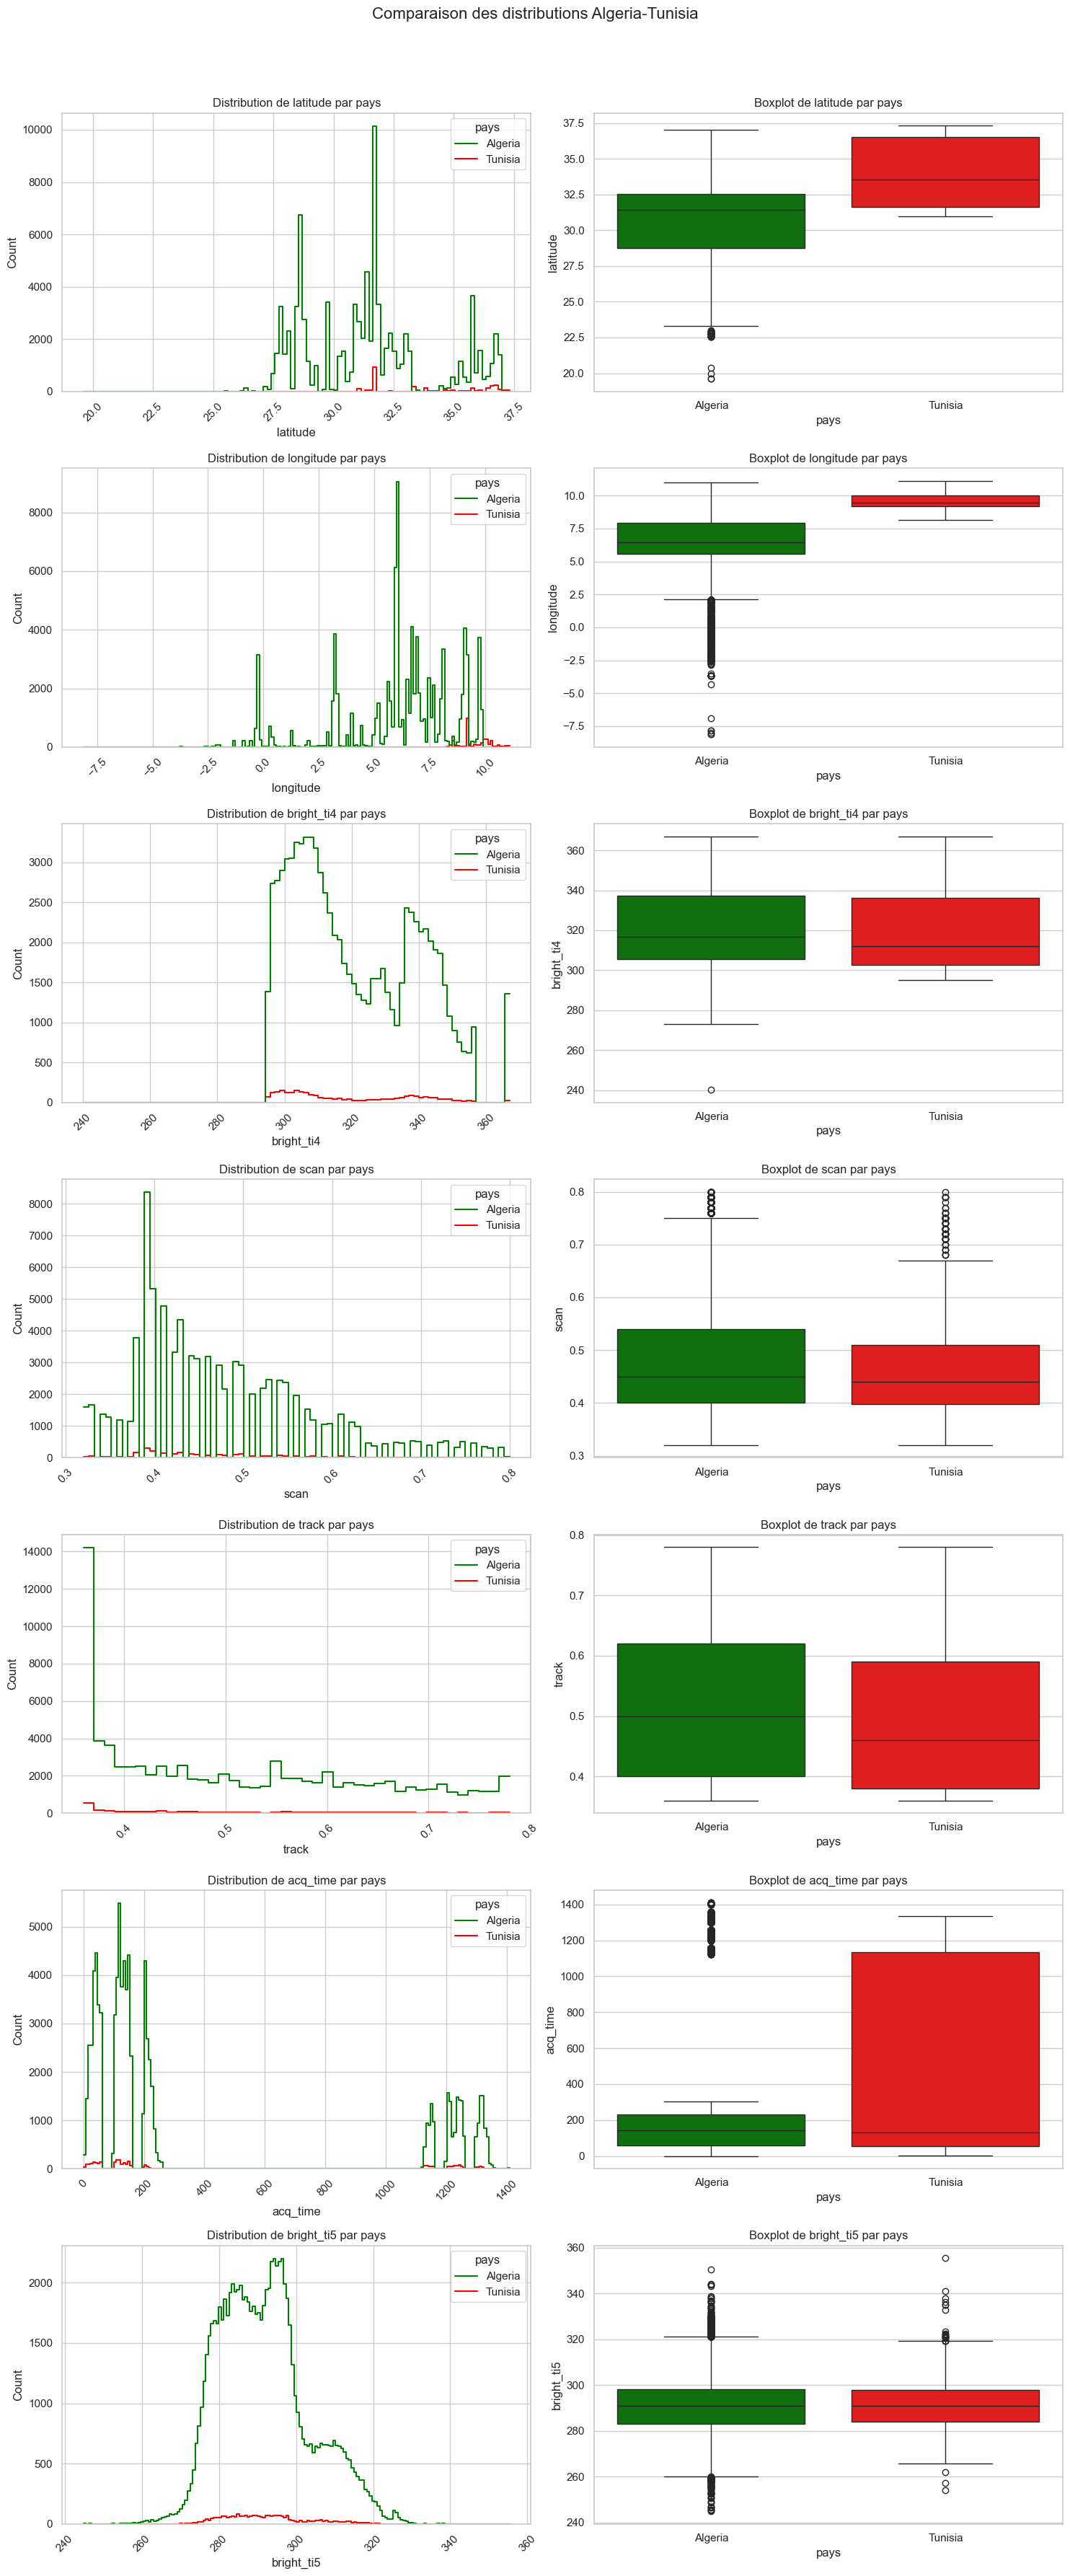

In [4]:
# Préparation des données pour la comparaison
# Ajout d'une colonne 'pays' pour identifier l'origine des données
algeria_fires['pays'] = 'Algeria'
tunisia_fires['pays'] = 'Tunisia'

# Combiner les deux datasets
combined_fires = pd.concat([algeria_fires, tunisia_fires])

# Fonction pour créer des visualisations comparatives
def plot_comparative_distributions(df, numeric_columns):
    # Exclure les colonnes spécifiées
    columns_to_exclude = ['version', 'frp', 'type']
    numeric_columns = [col for col in numeric_columns if col not in columns_to_exclude]
    n_cols = len(numeric_columns)
    
    # Définir les couleurs
    colors = {'Algeria': 'green', 'Tunisia': 'red'}
    
    # Création des subplots
    fig, axes = plt.subplots(n_cols, 2, figsize=(15, 5*n_cols))
    fig.suptitle('Comparaison des distributions Algeria-Tunisia', y=1.02, fontsize=16)
    
    # Si une seule colonne, convertir axes en tableau 2D
    if n_cols == 1:
        axes = np.array([axes])
    
    for i, col in enumerate(numeric_columns):
        # Histogramme sans KDE pour éviter les erreurs
        sns.histplot(data=df, x=col, hue='pays', ax=axes[i,0], 
                    element="step", fill=False,
                    palette=colors)
        axes[i,0].set_title(f'Distribution de {col} par pays')
        axes[i,0].tick_params(axis='x', rotation=45)
        
        # Boxplot avec hue au lieu de palette
        sns.boxplot(data=df, y=col, hue='pays', x='pays', ax=axes[i,1],
                   palette=colors, legend=False)
        axes[i,1].set_title(f'Boxplot de {col} par pays')
    
    plt.tight_layout()
    plt.show()

# Sélection des colonnes numériques communes
numeric_cols = combined_fires.select_dtypes(include=['float64', 'int64']).columns
plot_comparative_distributions(combined_fires, numeric_cols)

# 4 - Analyse bivariée

Correlation matrix, scatterplots and heatmaps between numeric variables.

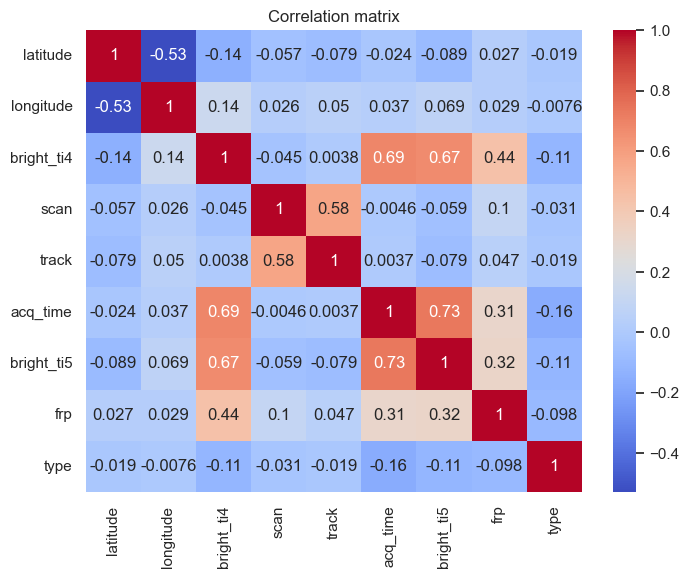

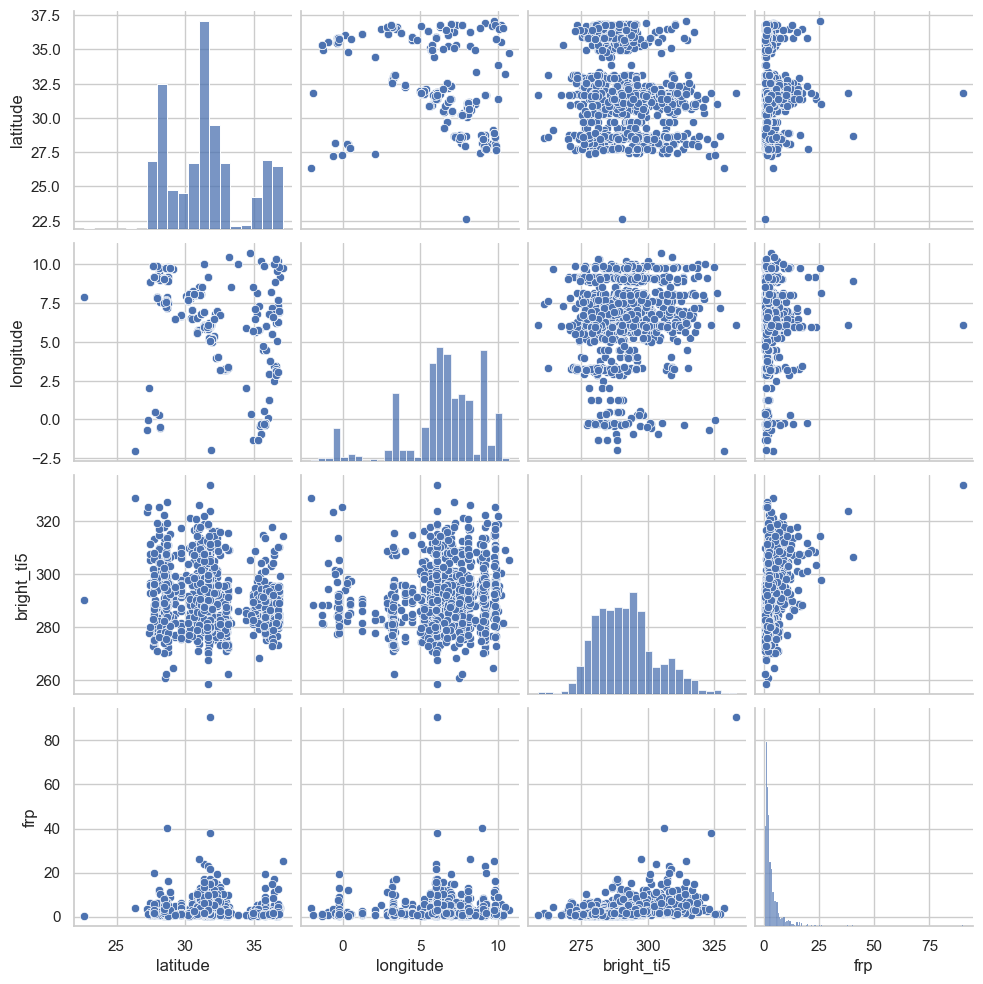

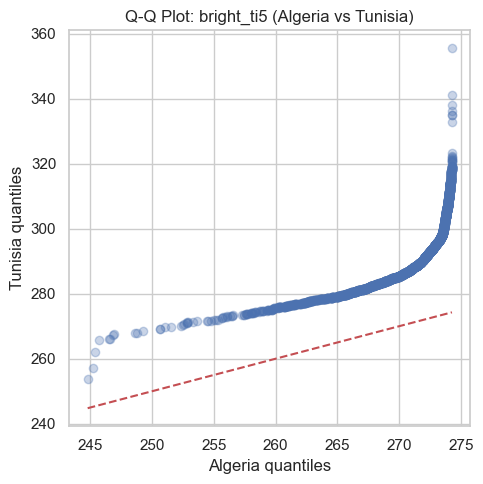

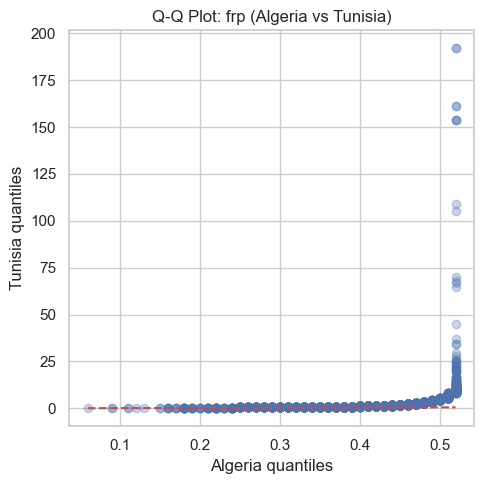

In [5]:
def qq_compare(df, country_col='pays', features=['bright_ti5', 'frp']):
    countries = df[country_col].unique()
    if len(countries) < 2:
        print("Need at least two countries for Q-Q comparison.")
        return
    c1, c2 = countries[:2]
    for feat in features:
        if feat not in df.columns:
            continue
        data1 = df[df[country_col] == c1][feat].dropna()
        data2 = df[df[country_col] == c2][feat].dropna()
        min_len = min(len(data1), len(data2))
        if min_len == 0:
            continue
        # Sort and align quantiles
        q1 = np.sort(data1)[:min_len]
        q2 = np.sort(data2)[:min_len]
        plt.figure(figsize=(5,5))
        plt.scatter(q1, q2, alpha=0.3)
        plt.plot([q1.min(), q1.max()], [q1.min(), q1.max()], 'r--')
        plt.xlabel(f'{c1} quantiles')
        plt.ylabel(f'{c2} quantiles')
        plt.title(f'Q-Q Plot: {feat} ({c1} vs {c2})')
        plt.tight_layout()
        plt.show()


def plot_bivariate(df, exclude_cols=None):
    if df is None:
        return
    if exclude_cols is None:
        exclude_cols = []
    numeric = df.select_dtypes(include=['number']).columns
    numeric = [c for c in numeric if c not in exclude_cols]
    if len(numeric) < 2:
        print('Not enough numeric columns for bivariate plots')
        return
    
    # Correlation matrix
    corr = df[numeric].corr()
    plt.figure(figsize=(8,6))
    sns.heatmap(corr, annot=True, cmap='coolwarm')
    plt.title('Correlation matrix')
    plt.show()
    # Select only relevant features for pairwise scatter
    relevant_features = ['latitude', 'longitude', 'bright_ti5', 'frp']

    # Pairwise scatter (sample if large)
    sample = df[relevant_features].dropna()
    if sample.shape[0] > 1000:
        sample = sample.sample(1000, random_state=0)
    sns.pairplot(sample)
    plt.show()

    # Q-Q plots
    qq_compare(combined_fires, features=['bright_ti5', 'frp'])

    
plot_bivariate(pd.concat([algeria_fires,tunisia_fires], ignore_index=True), exclude_cols=["version"])

# Distribution of the fire types

Original Data:


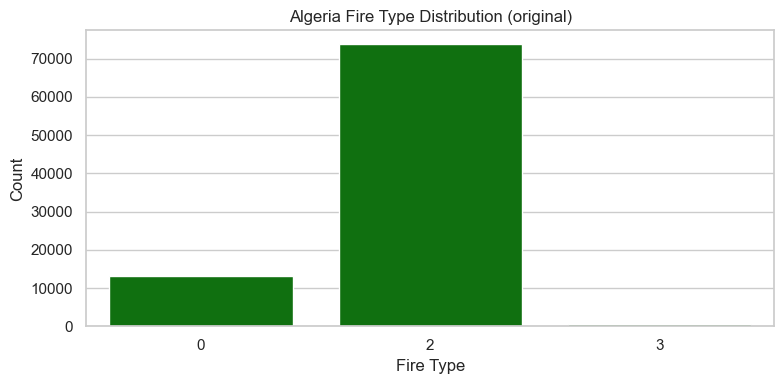


Algeria fire type counts:
type
0    13216
2    73694
3      536
Name: count, dtype: int64


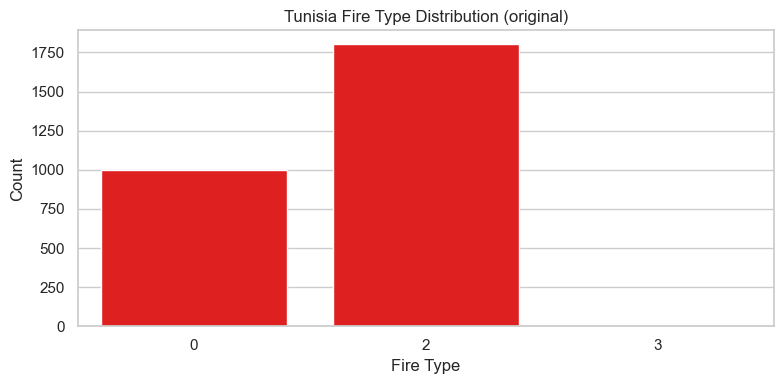


Tunisia fire type counts:
type
0    1000
2    1801
3       3
Name: count, dtype: int64


In [6]:
def plot_fire_type_distribution(df, country_name, color, title_suffix=''):
    if df is None or 'type' not in df.columns:
        print(f'No type column in {country_name} dataset')
        return
    type_counts = df['type'].value_counts().sort_index()
    plt.figure(figsize=(8,4))
    sns.barplot(x=type_counts.index, y=type_counts.values, color=color)
    plt.title(f'{country_name} Fire Type Distribution {title_suffix}')
    plt.xlabel('Fire Type')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
    # Print actual counts
    print(f"\n{country_name} fire type counts:")
    print(type_counts)

# 1) Original datasets (separate plots)
print("Original Data:")
plot_fire_type_distribution(algeria_fires, 'Algeria', 'green', '(original)')
plot_fire_type_distribution(tunisia_fires, 'Tunisia', 'red', '(original)')

# 5 - Analyse Temporelle

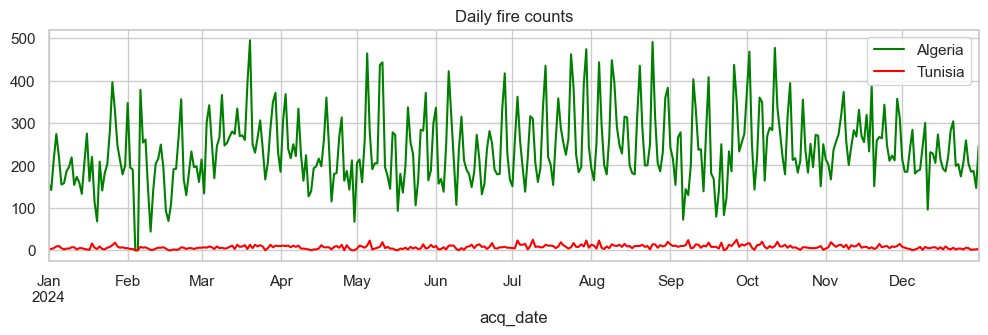

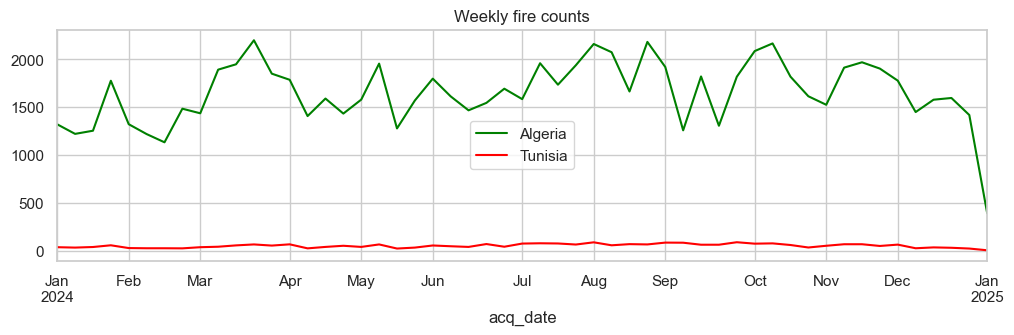

In [7]:
def temporal_analysis_dual(df1, df2, label1='Algeria', label2='Tunisia', date_col_candidates=['acq_date','acq_datetime','date','time']):
    # Find date column for each
    def get_date_col(df):
        for c in date_col_candidates:
            if c in df.columns:
                return c
        return None
    col1 = get_date_col(df1)
    col2 = get_date_col(df2)
    if col1 is None or col2 is None:
        print('No date column found in one of the datasets')
        return
    d1 = df1.copy()
    d2 = df2.copy()
    d1[col1] = pd.to_datetime(d1[col1], errors='coerce')
    d2[col2] = pd.to_datetime(d2[col2], errors='coerce')
    d1 = d1.dropna(subset=[col1]).set_index(col1)
    d2 = d2.dropna(subset=[col2]).set_index(col2)
    # Daily counts
    c1 = d1.resample('D').size()
    c2 = d2.resample('D').size()
    plt.figure(figsize=(12,3))
    c1.plot(label=label1, color='green')
    c2.plot(label=label2, color='red')
    plt.title('Daily fire counts')
    plt.legend()
    plt.show()
    # Weekly counts
    w1 = d1.resample('W').size()
    w2 = d2.resample('W').size()
    plt.figure(figsize=(12,3))
    w1.plot(label=label1, color='green')
    w2.plot(label=label2, color='red')
    plt.title('Weekly fire counts')
    plt.legend()
    plt.show()

# Example
# temporal_analysis_dual(algeria_clean, tunisia_clean)
temporal_analysis_dual(algeria_fires, tunisia_fires, label1='Algeria', label2='Tunisia')


# 6 - Analyse Spatiale

PLOT 1: RAW FIRE DATA (ALL TYPES)
[LOAD] Loading Algeria landcover shapefile...
[LOAD] Loading Tunisia landcover shapefile...

[STEP 1] Saving raw concatenated data...
  Saved raw data to: C:\Users\Azur\Downloads\TP\DM\results\data\fires.csv
  Total rows: 90,250

[STEP 2] Loading data from FIRES_CSV for visualization...
Raw data (all fire types) from fires.csv:
  Algeria: 87,446 points
  Tunisia: 2,804 points
  Total: 90,250 points


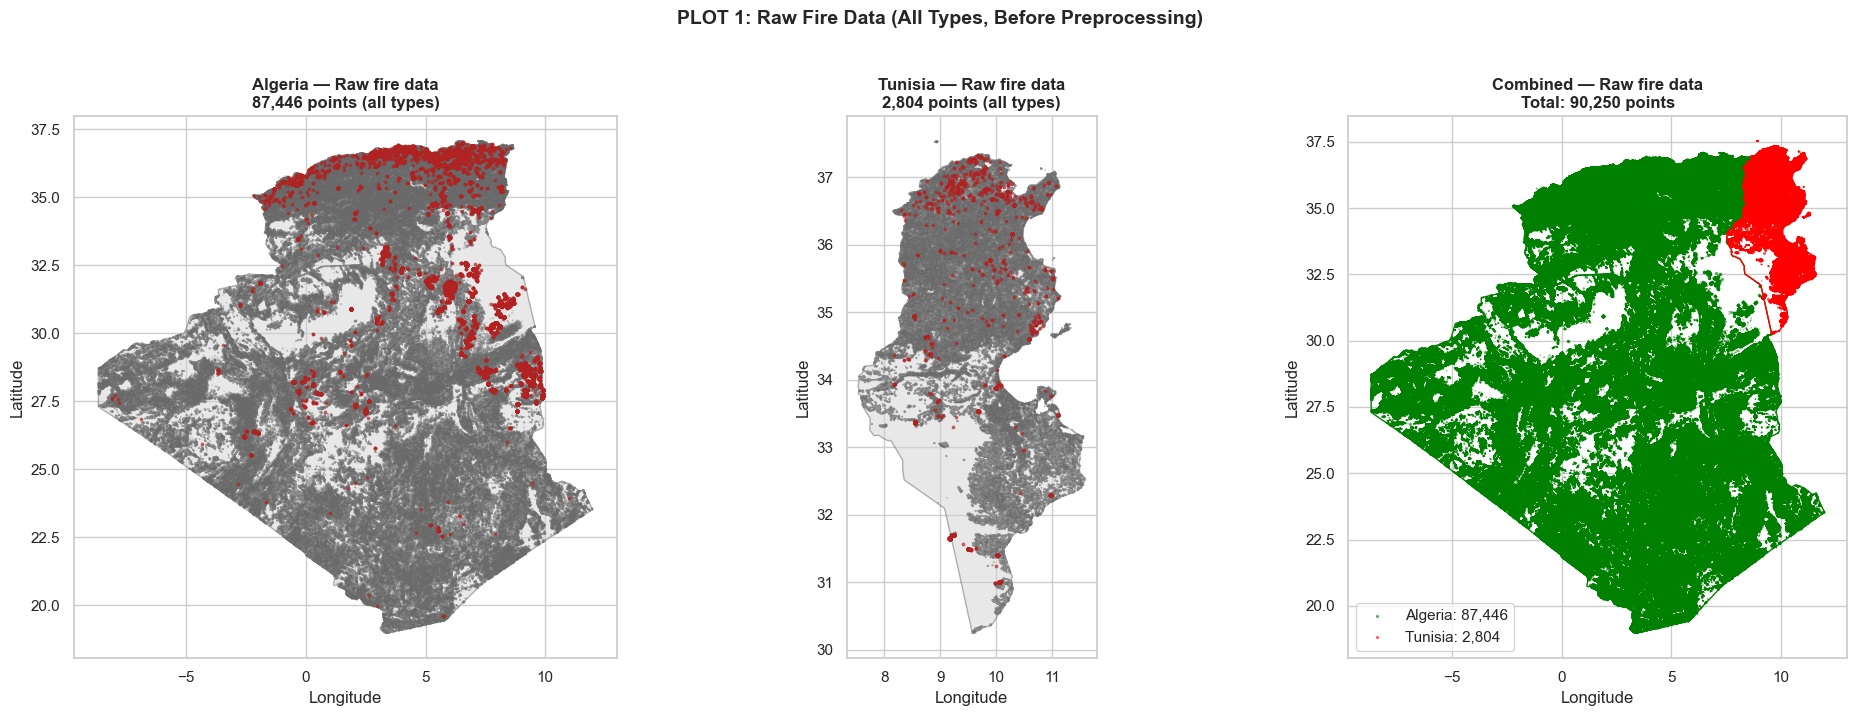


Fire type distribution:
  {0: 14216, 2: 75495, 3: 539}

✓ Raw data saved to: C:\Users\Azur\Downloads\TP\DM\results\data\fires.csv


In [8]:
# ============================================================================
# PLOT 1: RAW DATA (All fire types, before preprocessing)
# ============================================================================
print("="*80)
print("PLOT 1: RAW FIRE DATA (ALL TYPES)")
print("="*80)

# Load landcover data for boundaries (cache if not already loaded)
if 'algeria_lc' not in dir() or algeria_lc is None:
    print("[LOAD] Loading Algeria landcover shapefile...")
    algeria_lc = gpd.read_file(ALGERIA_SHP)
else:
    print("[CACHE] Using cached Algeria landcover data")

if 'tunisia_lc' not in dir() or tunisia_lc is None:
    print("[LOAD] Loading Tunisia landcover shapefile...")
    tunisia_lc = gpd.read_file(TUNISIA_SHP)
else:
    print("[CACHE] Using cached Tunisia landcover data")

# ============================================================================
# STEP 1: Save raw concatenated data to FIRES_CSV
# ============================================================================
print("\n[STEP 1] Saving raw concatenated data...")
raw_combined = pd.concat([algeria_fires, tunisia_fires], ignore_index=True)
raw_combined.to_csv(FIRES_CSV, index=False)
print(f"  Saved raw data to: {FIRES_CSV}")
print(f"  Total rows: {len(raw_combined):,}")

# ============================================================================
# STEP 2: Load from FIRES_CSV for plotting
# ============================================================================
print("\n[STEP 2] Loading data from FIRES_CSV for visualization...")
raw_df = pd.read_csv(FIRES_CSV)

# Separate by country (using pays column)
algeria_raw = raw_df[raw_df['pays'] == 'Algeria'].copy()
tunisia_raw = raw_df[raw_df['pays'] == 'Tunisia'].copy()

print(f"Raw data (all fire types) from {FIRES_CSV.name}:")
print(f"  Algeria: {len(algeria_raw):,} points")
print(f"  Tunisia: {len(tunisia_raw):,} points")
print(f"  Total: {len(raw_df):,} points")

# Create geodataframes
def create_fire_gdf(df):
    return gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
        crs='EPSG:4326'
    )

alg_gdf = create_fire_gdf(algeria_raw)
tn_gdf = create_fire_gdf(tunisia_raw)

# Create side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Left: Algeria
ax1 = axes[0]
algeria_lc.plot(ax=ax1, edgecolor='dimgray', facecolor='lightgray', alpha=0.5)
alg_gdf.plot(ax=ax1, markersize=3, color='firebrick', alpha=0.6)
ax1.set_title(f'Algeria — Raw fire data\n{len(algeria_raw):,} points (all types)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')

# Middle: Tunisia
ax2 = axes[1]
tunisia_lc.plot(ax=ax2, edgecolor='dimgray', facecolor='lightgray', alpha=0.5)
tn_gdf.plot(ax=ax2, markersize=3, color='firebrick', alpha=0.6)
ax2.set_title(f'Tunisia — Raw fire data\n{len(tunisia_raw):,} points (all types)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')

# Right: Combined view
ax3 = axes[2]
algeria_lc.plot(ax=ax3, edgecolor='green', facecolor='none', linewidth=1)
tunisia_lc.plot(ax=ax3, edgecolor='red', facecolor='none', linewidth=1)
alg_gdf.plot(ax=ax3, markersize=2, color='green', alpha=0.5, label=f'Algeria: {len(algeria_raw):,}')
tn_gdf.plot(ax=ax3, markersize=2, color='red', alpha=0.5, label=f'Tunisia: {len(tunisia_raw):,}')
ax3.set_title(f'Combined — Raw fire data\nTotal: {len(raw_df):,} points', fontsize=12, fontweight='bold')
ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')
ax3.legend(loc='lower left')

plt.suptitle('PLOT 1: Raw Fire Data (All Types, Before Preprocessing)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nFire type distribution:")
print(f"  {raw_df['type'].value_counts().sort_index().to_dict()}")
print(f"\n✓ Raw data saved to: {FIRES_CSV}")

# 7 - Data Preprocessing

Includes cleaning (missing values, duplicates, outliers) and clipping utilities.

In [9]:
print("="*80)
print("DATA PREPROCESSING PIPELINE")
print("="*80)

# ============================================================================
# CHECK IF PREPROCESSING CAN BE SKIPPED
# ============================================================================
FORCE_REPROCESS = False  # Set to True to force reprocessing even if file exists

_skip_preprocessing = False
if not FORCE_REPROCESS and FIRES_SUPERVISED_CSV.exists() and FIRES_UNSUPERVISED_CSV.exists():
    try:
        _existing_supervised = pd.read_csv(FIRES_SUPERVISED_CSV)
        _existing_unsupervised = pd.read_csv(FIRES_UNSUPERVISED_CSV)
        _required_cols = {'longitude', 'latitude', 'class'}
        
        _valid_supervised = (_required_cols.issubset(set(_existing_supervised.columns)) and 
                            len(_existing_supervised) > 0 and 
                            (_existing_supervised['class'] == 1).all())
        _valid_unsupervised = (_required_cols.issubset(set(_existing_unsupervised.columns)) and 
                              len(_existing_unsupervised) > 0 and 
                              (_existing_unsupervised['class'] == 1).all())
        
        if _valid_supervised and _valid_unsupervised:
            print(f"✓ [SKIP] Preprocessed data already exists")
            print(f"  SUPERVISED:   {FIRES_SUPERVISED_CSV.name} ({len(_existing_supervised):,} rows, lat > 33°)")
            print(f"  UNSUPERVISED: {FIRES_UNSUPERVISED_CSV.name} ({len(_existing_unsupervised):,} rows, full coverage)")
            fires_supervised = _existing_supervised
            fires_unsupervised = _existing_unsupervised
            print("  Set FORCE_REPROCESS=True to reprocess")
            _skip_preprocessing = True
            del _existing_supervised, _existing_unsupervised
    except Exception as e:
        print(f"[INFO] Could not load existing files: {e}. Running preprocessing...")

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def exclude_type_2_fires(df, verbose=True):
    """Keep only type 0 fires from dataset."""
    if df is None or 'type' not in df.columns:
        return df
    
    if verbose:
        print(f"Before: {len(df)} rows")
        print(f"Fire types distribution before filtering:")
        print(df['type'].value_counts().sort_index())
    
    df_clean = df[df['type'] == 0].copy()
    
    if verbose:
        print(f"After: {len(df_clean)} rows")
        print(f"Removed: {len(df) - len(df_clean)} rows with type != 0")
    
    return df_clean


def drop_duplicates_from_df(df, verbose=True):
    """Remove duplicate rows."""
    if df is None:
        return df
    
    if verbose:
        duplicates_count = df.duplicated().sum()
        print(f"Before: {len(df)} rows")
    df_clean = df.drop_duplicates()
    if verbose:
        print(f"After: {len(df_clean)} rows")
        print(f"Removed: {duplicates_count} duplicate rows")
    return df_clean


def fill_missing_values(df, verbose=True):
    """Fill missing values based on column type."""
    if df is None:
        return df
    
    df_clean = df.copy()
    
    # Check initial missing values
    if verbose:
        missing_before = df_clean.isnull().sum()
        if missing_before.sum() > 0:
            print("\nMissing values per column BEFORE filling:")
            print(missing_before[missing_before > 0])
    
    # Identify column types
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    date_cols = []
    categorical_cols = []
    
    for col in df_clean.columns:
        if col in numeric_cols:
            continue
        if 'date' in col.lower() or 'time' in col.lower():
            date_cols.append(col)
        else:
            categorical_cols.append(col)
    
    if verbose:
        print(f"\nColumn types identified:")
        print(f"  Numeric: {numeric_cols}")
        print(f"  Date: {date_cols}")
        print(f"  Categorical: {categorical_cols}")
    
    # Fill numeric columns with MEDIAN
    if numeric_cols:
        if verbose:
            print("\nFilling numeric columns with MEDIAN...")
        for col in numeric_cols:
            if df_clean[col].isnull().sum() > 0:
                median_val = df_clean[col].median()
                df_clean[col].fillna(median_val, inplace=True)
                if verbose:
                    print(f"  {col}: filled with {median_val}")
    
    # Fill date columns with INTERPOLATION
    if date_cols:
        if verbose:
            print("\nFilling date columns with INTERPOLATION...")
        for col in date_cols:
            if df_clean[col].isnull().sum() > 0:
                df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')
                df_clean[col] = pd.to_datetime(
                    df_clean[col].astype(np.int64).interpolate(method='linear').astype(np.int64),
                    errors='coerce'
                )
                df_clean[col].ffill(inplace=True)
                df_clean[col].bfill(inplace=True)
                if verbose:
                    print(f"  {col}: interpolated")
    
    # Fill categorical columns with MODE
    if categorical_cols:
        if verbose:
            print("\nFilling categorical columns with MODE...")
        for col in categorical_cols:
            if df_clean[col].isnull().sum() > 0:
                mode_val = df_clean[col].mode()
                if len(mode_val) > 0:
                    df_clean[col].fillna(mode_val[0], inplace=True)
                    if verbose:
                        print(f"  {col}: filled with '{mode_val[0]}'")
    
    return df_clean


def add_class_column(df, class_value=1, verbose=True):
    """Add class column with specified value."""
    if df is None:
        return df
    
    df_clean = df.copy()
    df_clean['class'] = class_value
    if verbose:
        print(f"Column 'class' added with value {class_value}. Shape: {df_clean.shape}")
    return df_clean


def filter_by_latitude(df, min_latitude=33, verbose=True):
    """Remove rows with latitude below threshold."""
    if df is None or 'latitude' not in df.columns:
        return df
    
    if verbose:
        print(f"Before: {len(df)} rows")
        print(f"Latitude range before: [{df['latitude'].min():.2f}, {df['latitude'].max():.2f}]")
    
    rows_below = (df['latitude'] < min_latitude).sum()
    df_clean = df[df['latitude'] >= min_latitude].copy()
    
    if verbose:
        print(f"After: {len(df_clean)} rows")
        print(f"Removed: {rows_below} rows with latitude < {min_latitude}")
        print(f"Latitude range after: [{df_clean['latitude'].min():.2f}, {df_clean['latitude'].max():.2f}]")
    
    return df_clean


def replace_outliers(df, exclude_cols=['latitude', 'longitude', 'class'], verbose=True):
    """Replace outliers using IQR method."""
    if df is None:
        return df
    
    df_clean = df.copy()
    
    # Get numeric columns (excluding specified columns)
    numeric_cols = [col for col in df_clean.select_dtypes(include=[np.number]).columns 
                    if col not in exclude_cols]
    
    if verbose and numeric_cols:
        print(f"\nAnalyzing outliers in: {numeric_cols}")
    
    for col in numeric_cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers_mask = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
        outliers_count = outliers_mask.sum()
        
        if outliers_count > 0:
            median_val = df_clean[col].median()
            df_clean.loc[outliers_mask, col] = median_val
            if verbose:
                print(f"  {col}: Replaced {outliers_count} outliers ({100*outliers_count/len(df_clean):.2f}%) with median {median_val:.2f}")
    
    # Handle categorical columns
    categorical_cols = [col for col in df_clean.select_dtypes(include=['object']).columns]
    if categorical_cols and verbose:
        print(f"\nCategorical columns (using mode for rare values): {categorical_cols}")
    
    for col in categorical_cols:
        value_counts = df_clean[col].value_counts()
        rare_threshold = len(df_clean) * 0.01
        rare_values = value_counts[value_counts < rare_threshold].index
        
        if len(rare_values) > 0:
            mode_val = df_clean[col].mode()[0]
            rare_mask = df_clean[col].isin(rare_values)
            df_clean.loc[rare_mask, col] = mode_val
            if verbose:
                print(f"  {col}: Replaced {rare_mask.sum()} rare values with mode '{mode_val}'")
    
    return df_clean


def keep_columns(df, columns_to_keep, verbose=True):
    """Keep only specified columns."""
    if df is None:
        return df
    
    if verbose:
        print(f"Before: {df.shape[1]} columns")
    
    available_cols = [col for col in columns_to_keep if col in df.columns]
    df_clean = df[available_cols].copy()
    
    if verbose:
        print(f"After: {df_clean.shape[1]} columns")
        print(f"Columns kept: {available_cols}")
    
    return df_clean


def preprocess_dataset(df, name='Dataset', min_latitude=None, keep_cols=['longitude', 'latitude', 'class'], verbose=True):
    """
    Complete preprocessing pipeline for a single dataset.
    min_latitude=None means no latitude filtering.
    """
    if df is None:
        return None
    
    if verbose:
        print(f"\n{'='*60}")
        print(f"PREPROCESSING: {name}")
        print(f"{'='*60}")
        print(f"Initial shape: {df.shape}")
    
    # Apply preprocessing steps
    df_clean = exclude_type_2_fires(df, verbose=verbose)
    df_clean = drop_duplicates_from_df(df_clean, verbose=verbose)
    df_clean = fill_missing_values(df_clean, verbose=verbose)
    df_clean = add_class_column(df_clean, class_value=1, verbose=verbose)
    
    # Apply latitude filtering only if specified
    if min_latitude is not None:
        df_clean = filter_by_latitude(df_clean, min_latitude=min_latitude, verbose=verbose)
    elif verbose:
        print(f"Latitude filtering: SKIPPED (full geographic coverage)")
    
    df_clean = replace_outliers(df_clean, verbose=verbose)
    df_clean = keep_columns(df_clean, columns_to_keep=keep_cols, verbose=verbose)
    
    if verbose:
        print(f"\nFinal shape: {df_clean.shape}")
        print(f"{'='*60}\n")
    
    return df_clean


# ============================================================================
# MAIN PREPROCESSING (only if not skipped)
# ============================================================================
if not _skip_preprocessing:
    # Set latitude threshold
    latitude_bound = 33

    # ============================================================================
    # STEP 1: Save RAW concatenation to FIRES_CSV (before any filtering)
    # ============================================================================
    print("\n" + "="*80)
    print("STEP 1: SAVE RAW CONCATENATED DATA")
    print("="*80)
    
    combined_fires_raw = pd.concat([algeria_fires, tunisia_fires], ignore_index=True)
    combined_fires_raw.to_csv(FIRES_CSV, index=False)
    print(f"Raw combined dataset saved to: {FIRES_CSV}")
    print(f"  Shape: {combined_fires_raw.shape}")
    print(f"  Fire types distribution:")
    print(combined_fires_raw['type'].value_counts().sort_index())
    print(f"  Latitude range: [{combined_fires_raw['latitude'].min():.2f}, {combined_fires_raw['latitude'].max():.2f}]")

    # ============================================================================
    # STEP 2: Create SUPERVISED dataset (WITH latitude filtering > 33°)
    # ============================================================================
    print("\n" + "="*80)
    print("STEP 2: CREATE SUPERVISED DATASET (lat > 33° only)")
    print("="*80)
    print("Purpose: For supervised learning where both classes need same geographic region")

    fires_supervised = preprocess_dataset(
        combined_fires_raw.copy(),
        name='SUPERVISED (lat > 33°)',
        min_latitude=latitude_bound,  # Apply latitude filtering
        keep_cols=['longitude', 'latitude', 'class'],
        verbose=True
    )
    
    fires_supervised.to_csv(FIRES_SUPERVISED_CSV, index=False)
    print(f"✓ Saved to: {FIRES_SUPERVISED_CSV}")

    # ============================================================================
    # STEP 3: Create UNSUPERVISED dataset (WITHOUT latitude filtering)
    # ============================================================================
    print("\n" + "="*80)
    print("STEP 3: CREATE UNSUPERVISED DATASET (full geographic coverage)")
    print("="*80)
    print("Purpose: For unsupervised learning with full geographic representation")

    fires_unsupervised = preprocess_dataset(
        combined_fires_raw.copy(),
        name='UNSUPERVISED (full coverage)',
        min_latitude=None,  # NO latitude filtering
        keep_cols=['longitude', 'latitude', 'class'],
        verbose=True
    )
    
    fires_unsupervised.to_csv(FIRES_UNSUPERVISED_CSV, index=False)
    print(f"✓ Saved to: {FIRES_UNSUPERVISED_CSV}")

    # ============================================================================
    # SUMMARY
    # ============================================================================
    print("\n" + "="*80)
    print("PREPROCESSING COMPLETE - SUMMARY")
    print("="*80)
    print(f"\n📁 Output Files:")
    print(f"  1. {FIRES_CSV.name} (raw concatenation)")
    print(f"     → {len(combined_fires_raw):,} rows (Algeria + Tunisia, no filtering)")
    print(f"     → Latitude: [{combined_fires_raw['latitude'].min():.2f}, {combined_fires_raw['latitude'].max():.2f}]")
    print(f"  2. {FIRES_SUPERVISED_CSV.name} (preprocessed WITH lat filtering)")
    print(f"     → {len(fires_supervised):,} rows (type=0, lat > {latitude_bound}°, class=1)")
    print(f"     → Latitude: [{fires_supervised['latitude'].min():.2f}, {fires_supervised['latitude'].max():.2f}]")
    print(f"  3. {FIRES_UNSUPERVISED_CSV.name} (preprocessed WITHOUT lat filtering)")
    print(f"     → {len(fires_unsupervised):,} rows (type=0, full coverage, class=1)")
    print(f"     → Latitude: [{fires_unsupervised['latitude'].min():.2f}, {fires_unsupervised['latitude'].max():.2f}]")
    
    print(f"\n📊 Statistics:")
    print(f"  Original raw:     {len(combined_fires_raw):,} rows")
    print(f"  Supervised:       {len(fires_supervised):,} rows ({100*len(fires_supervised)/len(combined_fires_raw):.1f}% retained)")
    print(f"  Unsupervised:     {len(fires_unsupervised):,} rows ({100*len(fires_unsupervised)/len(combined_fires_raw):.1f}% retained)")
    print("\n" + "="*80)

# Display previews (works for both skipped and processed)
print("\n📊 SUPERVISED fire data preview (lat > 33° only):")
display(fires_supervised.head())
print(f"   Rows: {len(fires_supervised):,}")
print(f"   Latitude range: [{fires_supervised['latitude'].min():.2f}, {fires_supervised['latitude'].max():.2f}]")

print("\n📊 UNSUPERVISED fire data preview (full geographic coverage):")
display(fires_unsupervised.head())
print(f"   Rows: {len(fires_unsupervised):,}")
print(f"   Latitude range: [{fires_unsupervised['latitude'].min():.2f}, {fires_unsupervised['latitude'].max():.2f}]")

DATA PREPROCESSING PIPELINE

STEP 1: SAVE RAW CONCATENATED DATA
Raw combined dataset saved to: C:\Users\Azur\Downloads\TP\DM\results\data\fires.csv
  Shape: (90250, 16)
  Fire types distribution:
type
0    14216
2    75495
3      539
Name: count, dtype: int64
  Latitude range: [19.60, 37.32]

STEP 2: CREATE SUPERVISED DATASET (lat > 33° only)
Purpose: For supervised learning where both classes need same geographic region

PREPROCESSING: SUPERVISED (lat > 33°)
Initial shape: (90250, 16)
Before: 90250 rows
Fire types distribution before filtering:
type
0    14216
2    75495
3      539
Name: count, dtype: int64
After: 14216 rows
Removed: 76034 rows with type != 0
Before: 14216 rows
After: 14216 rows
Removed: 0 duplicate rows

Column types identified:
  Numeric: ['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_time', 'version', 'bright_ti5', 'frp', 'type']
  Date: ['acq_date']
  Categorical: ['satellite', 'instrument', 'confidence', 'daynight', 'pays']

Filling numeric columns

,longitude,latitude,class
5,5.53337,35.70751,1
166,2.46763,36.49380,1
167,2.47313,36.49316,1
168,2.46726,36.49249,1
169,2.47275,36.49182,1


   Rows: 3,285
   Latitude range: [33.02, 37.32]

📊 UNSUPERVISED fire data preview (full geographic coverage):


,longitude,latitude,class
5,5.53337,35.70751,1
13,6.46961,32.13579,1
20,6.97630,32.35563,1
64,9.39581,28.19791,1
67,9.49323,28.12826,1


   Rows: 14,216
   Latitude range: [19.60, 37.32]


PLOT 2: PREPROCESSED DATA (TYPE=0, CLASS=1)

Loading preprocessed data from fires.csv...
Preprocessed data (type=0 only, class=1) from fires.csv:
  Algeria: 87,446 fire points
  Tunisia: 2,804 fire points
  Total: 90,250 fire points


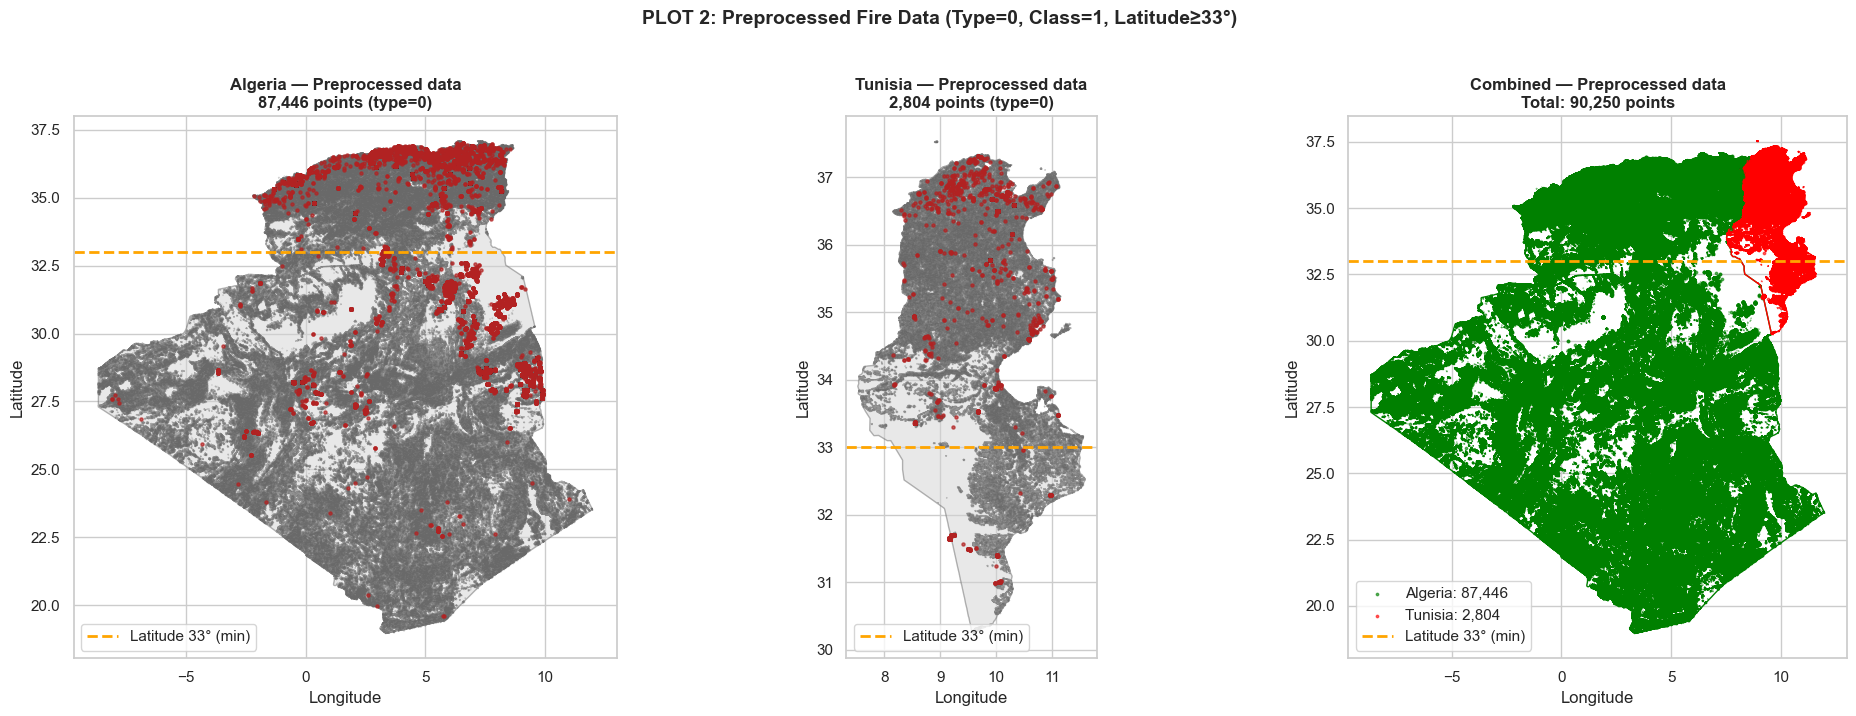


✓ Preprocessed data loaded from: C:\Users\Azur\Downloads\TP\DM\results\data\fires.csv


In [15]:
# ============================================================================
# PLOT 2: AFTER PREPROCESSING (Type=0 only, class=1)
# ============================================================================
print("="*80)
print("PLOT 2: PREPROCESSED DATA (TYPE=0, CLASS=1)")
print("="*80)

# ============================================================================
# Load preprocessed data from FIRES_CSV
# ============================================================================
print(f"\nLoading preprocessed data from {FIRES_CSV.name}...")
preprocessed_df = pd.read_csv(FIRES_CSV)

# Separate by country (using pays column)
algeria_preprocessed = preprocessed_df[preprocessed_df['pays'] == 'Algeria'].copy()
tunisia_preprocessed = preprocessed_df[preprocessed_df['pays'] == 'Tunisia'].copy()

print(f"Preprocessed data (type=0 only, class=1) from {FIRES_CSV.name}:")
print(f"  Algeria: {len(algeria_preprocessed):,} fire points")
print(f"  Tunisia: {len(tunisia_preprocessed):,} fire points")
print(f"  Total: {len(preprocessed_df):,} fire points")

# Create geodataframes
alg_clean_gdf = gpd.GeoDataFrame(
    algeria_preprocessed,
    geometry=gpd.points_from_xy(algeria_preprocessed['longitude'], algeria_preprocessed['latitude']),
    crs='EPSG:4326'
)
tn_clean_gdf = gpd.GeoDataFrame(
    tunisia_preprocessed,
    geometry=gpd.points_from_xy(tunisia_preprocessed['longitude'], tunisia_preprocessed['latitude']),
    crs='EPSG:4326'
)

# Create side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Left: Algeria
ax1 = axes[0]
algeria_lc.plot(ax=ax1, edgecolor='dimgray', facecolor='lightgray', alpha=0.5)
alg_clean_gdf.plot(ax=ax1, markersize=5, color='firebrick', alpha=0.7)
ax1.set_title(f'Algeria — Preprocessed data\n{len(algeria_preprocessed):,} points (type=0)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.axhline(y=33, color='orange', linestyle='--', linewidth=2, label='Latitude 33° (min)')
ax1.legend(loc='lower left')

# Middle: Tunisia
ax2 = axes[1]
tunisia_lc.plot(ax=ax2, edgecolor='dimgray', facecolor='lightgray', alpha=0.5)
tn_clean_gdf.plot(ax=ax2, markersize=5, color='firebrick', alpha=0.7)
ax2.set_title(f'Tunisia — Preprocessed data\n{len(tunisia_preprocessed):,} points (type=0)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.axhline(y=33, color='orange', linestyle='--', linewidth=2, label='Latitude 33° (min)')
ax2.legend(loc='lower left')

# Right: Combined view
ax3 = axes[2]
algeria_lc.plot(ax=ax3, edgecolor='green', facecolor='none', linewidth=1)
tunisia_lc.plot(ax=ax3, edgecolor='red', facecolor='none', linewidth=1)
alg_clean_gdf.plot(ax=ax3, markersize=3, color='green', alpha=0.6, label=f'Algeria: {len(algeria_preprocessed):,}')
tn_clean_gdf.plot(ax=ax3, markersize=3, color='red', alpha=0.6, label=f'Tunisia: {len(tunisia_preprocessed):,}')
ax3.set_title(f'Combined — Preprocessed data\nTotal: {len(preprocessed_df):,} points', fontsize=12, fontweight='bold')
ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')
ax3.axhline(y=33, color='orange', linestyle='--', linewidth=2, label='Latitude 33° (min)')
ax3.legend(loc='lower left')

plt.suptitle('PLOT 2: Preprocessed Fire Data (Type=0, Class=1, Latitude≥33°)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n✓ Preprocessed data loaded from: {FIRES_CSV}")

# 8 - Merging

In [18]:
# =============================================================================
# 8. Generate Artificial Non-Fire Data (Class 0) - Grid-Based Approach
# =============================================================================
# Produces TWO datasets:
# 1. SUPERVISED: Both Class 0 and Class 1 from lat > 33° only
#    - Uses FIRES_SUPERVISED_CSV as Class 1 source
#    - Generates Class 0 only from lat > 33° region
#    - Balanced 1:1 ratio (same number of Class 0 as Class 1)
# 2. UNSUPERVISED: Class 1 from full region, Class 0 with SAME geographic distribution as fires
#    - Uses FIRES_UNSUPERVISED_CSV as Class 1 source
#    - Generates Class 0 from entire region with matching fire distribution
#    - Balanced 1:1 ratio (same number of Class 0 as Class 1)

from shapely.geometry import Point, box
from shapely.ops import unary_union
from shapely.prepared import prep
import numpy as np

print("="*80)
print("GENERATING ARTIFICIAL NON-FIRE DATA (CLASS 0) - TWO DATASETS")
print("="*80)
print("\n📋 Output files:")
print(f"  1. SUPERVISED:   {FIRES_WITH_ARTIFICIAL_SUPERVISED.name}")
print(f"     → Class 0 and Class 1 BOTH from lat > 33° (no geographic shortcuts)")
print(f"     → Uses: {FIRES_SUPERVISED_CSV.name}")
print(f"  2. UNSUPERVISED: {FIRES_WITH_ARTIFICIAL_UNSUPERVISED.name}")
print(f"     → Class 0 AND Class 1 both with SAME geographic distribution")
print(f"     → Uses: {FIRES_UNSUPERVISED_CSV.name}")

# Force regeneration flag
FORCE_REPROCESS = True

# Check if both output files already exist with valid data
def check_existing_file(filepath):
    """Check if file exists with valid data."""
    if not filepath.exists():
        return None
    existing_df = pd.read_csv(filepath)
    if len(existing_df) > 0 and 'class' in existing_df.columns:
        class_counts = existing_df['class'].value_counts()
        if 0 in class_counts.index and 1 in class_counts.index:
            return existing_df
    return None

if not FORCE_REPROCESS:
    existing_supervised = check_existing_file(FIRES_WITH_ARTIFICIAL_SUPERVISED)
    existing_unsupervised = check_existing_file(FIRES_WITH_ARTIFICIAL_UNSUPERVISED)
    
    if existing_supervised is not None and existing_unsupervised is not None:
        print(f"\n✓ SKIPPING: Both files already exist with valid data")
        print(f"  Set FORCE_REPROCESS = True to regenerate")
        fires_with_artificial_supervised = existing_supervised
        fires_with_artificial_unsupervised = existing_unsupervised
else:
    existing_supervised = None
    existing_unsupervised = None

if existing_supervised is None or existing_unsupervised is None:
    # ============================================================================
    # STEP 1: Load fire data from preprocessed files
    # ============================================================================
    print(f"\n[STEP 1] Loading fire data (Class 1)")
    
    # Load SUPERVISED fire data (lat > 33° only)
    fires_supervised_df = pd.read_csv(FIRES_SUPERVISED_CSV)
    n_fires_supervised = len(fires_supervised_df)
    print(f"  SUPERVISED source: {FIRES_SUPERVISED_CSV.name}")
    print(f"    Rows: {n_fires_supervised:,}")
    print(f"    Latitude range: [{fires_supervised_df['latitude'].min():.2f}, {fires_supervised_df['latitude'].max():.2f}]")
    
    # Load UNSUPERVISED fire data (full coverage)
    fires_unsupervised_df = pd.read_csv(FIRES_UNSUPERVISED_CSV)
    n_fires_unsupervised = len(fires_unsupervised_df)
    print(f"  UNSUPERVISED source: {FIRES_UNSUPERVISED_CSV.name}")
    print(f"    Rows: {n_fires_unsupervised:,}")
    print(f"    Latitude range: [{fires_unsupervised_df['latitude'].min():.2f}, {fires_unsupervised_df['latitude'].max():.2f}]")

    # Create coordinate sets for duplicate checking
    fire_coords_supervised = set(zip(fires_supervised_df['longitude'].round(5), fires_supervised_df['latitude'].round(5)))
    fire_coords_unsupervised = set(zip(fires_unsupervised_df['longitude'].round(5), fires_unsupervised_df['latitude'].round(5)))

    # ============================================================================
    # STEP 2: Load and prepare boundaries
    # ============================================================================
    print(f"\n[STEP 2] Loading country boundaries")
    print(f"  Algeria: {len(algeria_lc)} polygons")
    print(f"  Tunisia: {len(tunisia_lc)} polygons")
    
    print("  Computing combined boundary...")
    algeria_boundary_geom = unary_union(algeria_lc.geometry)
    tunisia_boundary_geom = unary_union(tunisia_lc.geometry)
    combined_boundary = unary_union([algeria_boundary_geom, tunisia_boundary_geom])
    print(f"  ✓ Boundary computed: {combined_boundary.area:.2f} sq degrees")
    
    prepared_boundary = prep(combined_boundary)
    minx, miny, maxx, maxy = combined_boundary.bounds
    print(f"  Bounds: lon=[{minx:.2f}, {maxx:.2f}], lat=[{miny:.2f}, {maxy:.2f}]")

    # ============================================================================
    # STEP 3: Create grid cells
    # ============================================================================
    print(f"\n[STEP 3] Creating grid cells")
    
    grid_resolution = 0.1  # degrees (roughly 11km x 8.5km)
    latitude_threshold = 33
    
    # Generate grid cells
    grid_cells = []
    x = minx
    while x < maxx:
        y = miny
        while y < maxy:
            cell = {
                'x_min': x,
                'x_max': x + grid_resolution,
                'y_min': y,
                'y_max': y + grid_resolution,
                'lat': y + grid_resolution / 2,  # Center latitude
            }
            grid_cells.append(cell)
            y += grid_resolution
        x += grid_resolution
    
    print(f"  Total grid cells created: {len(grid_cells):,}")
    
    # Filter cells by latitude
    northern_cells = [c for c in grid_cells if c['lat'] > latitude_threshold]
    southern_cells = [c for c in grid_cells if c['lat'] <= latitude_threshold]
    
    print(f"  Northern cells (lat > {latitude_threshold}°): {len(northern_cells):,}")
    print(f"  Southern cells (lat ≤ {latitude_threshold}°): {len(southern_cells):,}")

    # ============================================================================
    # STEP 4: Calculate target points and geographic distribution
    # ============================================================================
    print(f"\n[STEP 4] Calculating target points and geographic distribution")
    
    # SUPERVISED: Same number of Class 0 as fires, ALL from lat > 33°
    target_artificial_supervised = n_fires_supervised  # 1:1 ratio
    
    # UNSUPERVISED: Same number of Class 0 as fires, with SAME geographic distribution as fires
    target_artificial_unsupervised = n_fires_unsupervised  # 1:1 ratio
    
    # Calculate natural fire distribution in unsupervised
    fires_north = (fires_unsupervised_df['latitude'] > latitude_threshold).sum()
    fires_south = (fires_unsupervised_df['latitude'] <= latitude_threshold).sum()
    north_pct_fires = fires_north / n_fires_unsupervised
    south_pct_fires = fires_south / n_fires_unsupervised
    
    # Apply same distribution to Class 0 artificial data
    target_north_unsupervised = int(target_artificial_unsupervised * north_pct_fires)
    target_south_unsupervised = target_artificial_unsupervised - target_north_unsupervised
    
    print(f"\n  📊 SUPERVISED target:")
    print(f"    Class 1 (fires): {n_fires_supervised:,}")
    print(f"    Class 0 (artificial): {target_artificial_supervised:,} (all from lat > {latitude_threshold}°)")
    print(f"    Total: {n_fires_supervised + target_artificial_supervised:,} (50/50 balanced)")
    
    print(f"\n  📊 UNSUPERVISED target:")
    print(f"    Class 1 fire distribution: {north_pct_fires*100:.1f}% North, {south_pct_fires*100:.1f}% South")
    print(f"    Class 1 (fires): {n_fires_unsupervised:,} ({fires_north:,} North / {fires_south:,} South)")
    print(f"    Class 0 (artificial): {target_artificial_unsupervised:,} (SAME distribution as fires)")
    print(f"      - Northern ({north_pct_fires*100:.1f}%): {target_north_unsupervised:,}")
    print(f"      - Southern ({south_pct_fires*100:.1f}%): {target_south_unsupervised:,}")
    print(f"    Total: {n_fires_unsupervised + target_artificial_unsupervised:,} (50/50 balanced)")

    # ============================================================================
    # STEP 5: Generate ALL valid grid points from both regions
    # ============================================================================
    print(f"\n[STEP 5] Generating all valid grid points...")
    
    # Calculate how many points we need to generate
    max_needed = max(target_artificial_supervised, target_artificial_unsupervised) + 1000  # buffer
    points_per_cell = max(5, (max_needed // len(grid_cells)) + 2)
    print(f"  Points per cell: {points_per_cell} (to generate ~{max_needed:,} points)")
    
    np.random.seed(42)
    all_grid_points = []
    
    # Combine fire coords from both datasets for initial filtering
    all_fire_coords = fire_coords_supervised.union(fire_coords_unsupervised)
    generated_coords = set()  # Track already generated coordinates
    
    # Generate from all grid cells
    for cell_idx, cell in enumerate(grid_cells):
        if (cell_idx + 1) % 500 == 0:
            print(f"  Processing cell {cell_idx + 1:,}/{len(grid_cells):,} ({len(all_grid_points):,} points so far)...")
        
        for _ in range(points_per_cell):
            x = np.random.uniform(cell['x_min'], cell['x_max'])
            y = np.random.uniform(cell['y_min'], cell['y_max'])
            
            point = Point(x, y)
            if not prepared_boundary.contains(point):
                continue
            
            x_r, y_r = round(x, 5), round(y, 5)
            
            # Skip if it's a fire location
            if (x_r, y_r) in all_fire_coords:
                continue
            
            # Skip if already generated
            if (x_r, y_r) in generated_coords:
                continue
            
            generated_coords.add((x_r, y_r))
            all_grid_points.append((x_r, y_r))
    
    print(f"  ✓ Generated {len(all_grid_points):,} valid grid points total")

    # ============================================================================
    # STEP 6: Separate by latitude and shuffle
    # ============================================================================
    print(f"\n[STEP 6] Separating points by latitude...")
    
    northern_grid = [(x, y) for x, y in all_grid_points if y > latitude_threshold]
    southern_grid = [(x, y) for x, y in all_grid_points if y <= latitude_threshold]
    
    print(f"  Available points:")
    print(f"    Northern (lat > {latitude_threshold}°): {len(northern_grid):,}")
    print(f"    Southern (lat ≤ {latitude_threshold}°): {len(southern_grid):,}")
    
    # Shuffle to avoid spatial clustering
    np.random.shuffle(northern_grid)
    np.random.shuffle(southern_grid)
    print(f"  ✓ Shuffled points to avoid spatial clustering")

    # ============================================================================
    # STEP 7A: Create SUPERVISED dataset (Class 0 only from lat > 33°)
    # ============================================================================
    print(f"\n[STEP 7A] Creating SUPERVISED dataset")
    print(f"  Constraint: Class 0 ONLY from lat > {latitude_threshold}°")
    
    # Select northern points for supervised (excluding any that overlap with supervised fires)
    selected_supervised = []
    for x, y in northern_grid:
        if (x, y) not in fire_coords_supervised:
            selected_supervised.append((x, y))
        if len(selected_supervised) >= target_artificial_supervised:
            break
    
    print(f"  Selected {len(selected_supervised):,} / {target_artificial_supervised:,} target Class 0 points")
    
    artificial_supervised_df = pd.DataFrame(selected_supervised, columns=['longitude', 'latitude'])
    artificial_supervised_df['class'] = 0
    
    # Combine with fires (which are already lat > 33°)
    fires_df_supervised_clean = fires_supervised_df[['longitude', 'latitude', 'class']].copy()
    fires_with_artificial_supervised = pd.concat([fires_df_supervised_clean, artificial_supervised_df], ignore_index=True)
    
    # Shuffle and save
    fires_with_artificial_supervised = fires_with_artificial_supervised.sample(frac=1, random_state=42).reset_index(drop=True)
    fires_with_artificial_supervised.to_csv(FIRES_WITH_ARTIFICIAL_SUPERVISED, index=False)
    print(f"  ✓ Saved to: {FIRES_WITH_ARTIFICIAL_SUPERVISED}")

    # ============================================================================
    # STEP 7B: Create UNSUPERVISED dataset (Class 0 with matching fire distribution)
    # ============================================================================
    print(f"\n[STEP 7B] Creating UNSUPERVISED dataset")
    print(f"  Constraint: Class 0 with SAME geographic split as fires ({north_pct_fires*100:.1f}% north, {south_pct_fires*100:.1f}% south)")
    
    # Select points for unsupervised (excluding any that overlap with unsupervised fires)
    selected_north_unsupervised = []
    for x, y in northern_grid:
        if (x, y) not in fire_coords_unsupervised:
            selected_north_unsupervised.append((x, y))
        if len(selected_north_unsupervised) >= target_north_unsupervised:
            break
    
    selected_south_unsupervised = []
    for x, y in southern_grid:
        if (x, y) not in fire_coords_unsupervised:
            selected_south_unsupervised.append((x, y))
        if len(selected_south_unsupervised) >= target_south_unsupervised:
            break
    
    all_artificial_unsupervised = selected_north_unsupervised + selected_south_unsupervised
    
    print(f"  Selected points:")
    print(f"    Northern: {len(selected_north_unsupervised):,} / {target_north_unsupervised:,} target")
    print(f"    Southern: {len(selected_south_unsupervised):,} / {target_south_unsupervised:,} target")
    print(f"    Total: {len(all_artificial_unsupervised):,} / {target_artificial_unsupervised:,} target")
    
    artificial_unsupervised_df = pd.DataFrame(all_artificial_unsupervised, columns=['longitude', 'latitude'])
    artificial_unsupervised_df['class'] = 0
    
    # Combine with fires (full coverage)
    fires_df_unsupervised_clean = fires_unsupervised_df[['longitude', 'latitude', 'class']].copy()
    fires_with_artificial_unsupervised = pd.concat([fires_df_unsupervised_clean, artificial_unsupervised_df], ignore_index=True)
    
    # Shuffle and save
    fires_with_artificial_unsupervised = fires_with_artificial_unsupervised.sample(frac=1, random_state=42).reset_index(drop=True)
    fires_with_artificial_unsupervised.to_csv(FIRES_WITH_ARTIFICIAL_UNSUPERVISED, index=False)
    print(f"  ✓ Saved to: {FIRES_WITH_ARTIFICIAL_UNSUPERVISED}")

    # ============================================================================
    # SUMMARY
    # ============================================================================
    print("\n" + "="*80)
    print("SUMMARY - TWO DATASETS GENERATED")
    print("="*80)
    
    # Supervised summary
    print(f"\n📊 SUPERVISED DATASET: {FIRES_WITH_ARTIFICIAL_SUPERVISED.name}")
    print(f"   Shape: {fires_with_artificial_supervised.shape}")
    sup_counts = fires_with_artificial_supervised['class'].value_counts().sort_index()
    for cls in [0, 1]:
        if cls in sup_counts.index:
            count = sup_counts[cls]
            pct = 100 * count / len(fires_with_artificial_supervised)
            class_name = "non-fire" if cls == 0 else "fire"
            print(f"   Class {cls} ({class_name}): {count:>5,} ({pct:.1f}%)")
    
    sup_c0 = fires_with_artificial_supervised[fires_with_artificial_supervised['class'] == 0]
    sup_c1 = fires_with_artificial_supervised[fires_with_artificial_supervised['class'] == 1]
    sup_c0_lat_check = (sup_c0['latitude'] > latitude_threshold).all()
    sup_c1_lat_check = (sup_c1['latitude'] > latitude_threshold).all()
    print(f"   Class 0 all lat > {latitude_threshold}°: {sup_c0_lat_check} ✓")
    print(f"   Class 1 all lat > {latitude_threshold}°: {sup_c1_lat_check} ✓")
    print(f"   Latitude range: [{fires_with_artificial_supervised['latitude'].min():.2f}, {fires_with_artificial_supervised['latitude'].max():.2f}]")
    print(f"   → Use for: KNN, Decision Tree, Random Forest (supervised classification)")
    
    # Unsupervised summary
    print(f"\n📊 UNSUPERVISED DATASET: {FIRES_WITH_ARTIFICIAL_UNSUPERVISED.name}")
    print(f"   Shape: {fires_with_artificial_unsupervised.shape}")
    unsup_counts = fires_with_artificial_unsupervised['class'].value_counts().sort_index()
    for cls in [0, 1]:
        if cls in unsup_counts.index:
            count = unsup_counts[cls]
            pct = 100 * count / len(fires_with_artificial_unsupervised)
            class_name = "non-fire" if cls == 0 else "fire"
            print(f"   Class {cls} ({class_name}): {count:>5,} ({pct:.1f}%)")
    
    unsup_c0 = fires_with_artificial_unsupervised[fires_with_artificial_unsupervised['class'] == 0]
    unsup_c1 = fires_with_artificial_unsupervised[fires_with_artificial_unsupervised['class'] == 1]
    
    unsup_c0_north = len(unsup_c0[unsup_c0['latitude'] > latitude_threshold])
    unsup_c0_south = len(unsup_c0[unsup_c0['latitude'] <= latitude_threshold])
    unsup_c1_north = len(unsup_c1[unsup_c1['latitude'] > latitude_threshold])
    unsup_c1_south = len(unsup_c1[unsup_c1['latitude'] <= latitude_threshold])
    
    print(f"   Class 0 geographic distribution:")
    print(f"     Northern (lat > {latitude_threshold}°): {unsup_c0_north:,} ({100*unsup_c0_north/len(unsup_c0):.1f}%)")
    print(f"     Southern (lat ≤ {latitude_threshold}°): {unsup_c0_south:,} ({100*unsup_c0_south/len(unsup_c0):.1f}%)")
    print(f"   Class 1 geographic distribution:")
    print(f"     Northern (lat > {latitude_threshold}°): {unsup_c1_north:,} ({100*unsup_c1_north/len(unsup_c1):.1f}%)")
    print(f"     Southern (lat ≤ {latitude_threshold}°): {unsup_c1_south:,} ({100*unsup_c1_south/len(unsup_c1):.1f}%)")
    print(f"   Latitude range: [{fires_with_artificial_unsupervised['latitude'].min():.2f}, {fires_with_artificial_unsupervised['latitude'].max():.2f}]")
    print(f"   ✓ Both classes have matching geographic patterns (no latitude shortcut)")
    print(f"   → Use for: K-Means, DBSCAN, CLARANS (unsupervised clustering)")
    
    print("\n" + "="*80)
    print("✓ Both datasets saved successfully!")
    print("="*80)

GENERATING ARTIFICIAL NON-FIRE DATA (CLASS 0) - TWO DATASETS

📋 Output files:
  1. SUPERVISED:   fires_with_artificial_supervised.csv
     → Class 0 and Class 1 BOTH from lat > 33° (no geographic shortcuts)
     → Uses: fires_supervised.csv
  2. UNSUPERVISED: fires_with_artificial_unsupervised.csv
     → Class 0 AND Class 1 both with SAME geographic distribution
     → Uses: fires_unsupervised.csv

[STEP 1] Loading fire data (Class 1)
  SUPERVISED source: fires_supervised.csv
    Rows: 3,285
    Latitude range: [33.02, 37.32]
  UNSUPERVISED source: fires_unsupervised.csv
    Rows: 14,216
    Latitude range: [19.60, 37.32]

[STEP 2] Loading country boundaries
  Algeria: 386454 polygons
  Tunisia: 52059 polygons
  Computing combined boundary...
  ✓ Boundary computed: 228.61 sq degrees
  Bounds: lon=[-8.67, 11.98], lat=[18.96, 37.54]

[STEP 3] Creating grid cells
  Total grid cells created: 38,502
  Northern cells (lat > 33°): 9,522
  Southern cells (lat ≤ 33°): 28,980

[STEP 4] Calculati

PLOT 3: SUPERVISED vs UNSUPERVISED DATASETS COMPARISON
SUPERVISED dataset: (6570, 3)
UNSUPERVISED dataset: (28432, 3)


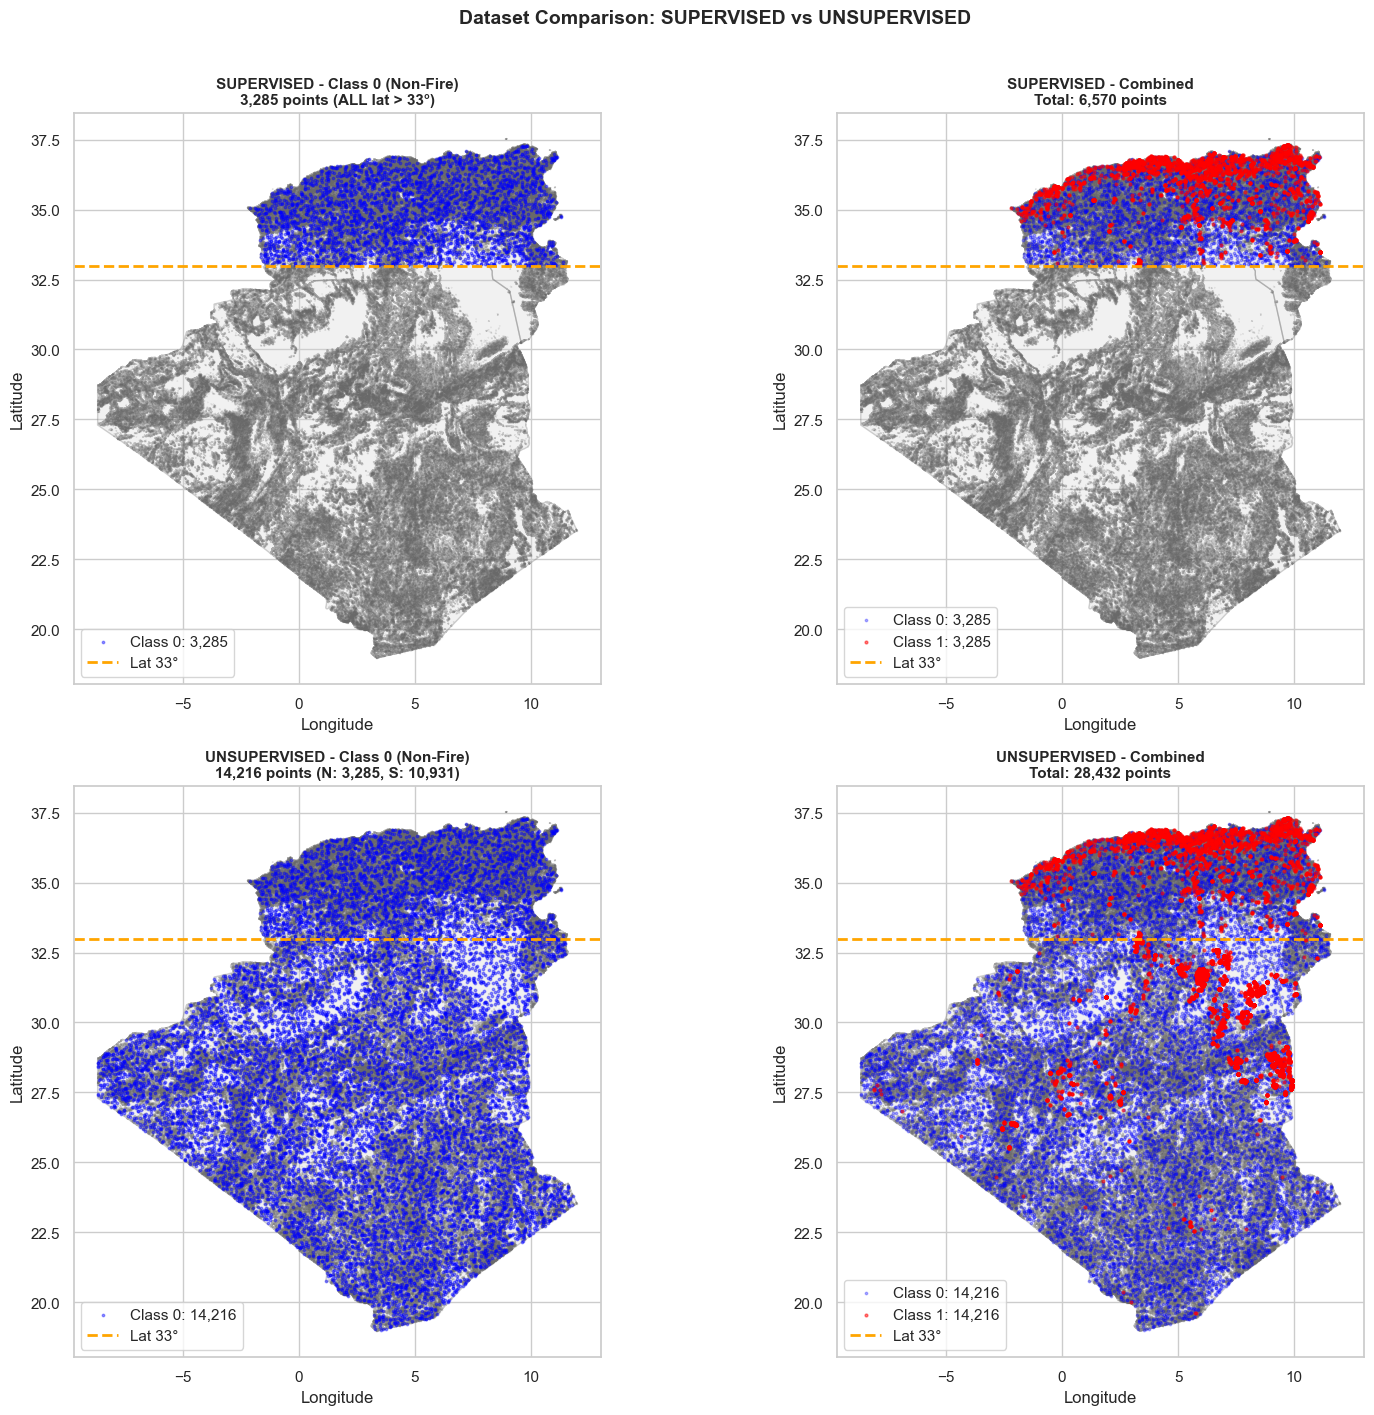


DATASET COMPARISON SUMMARY

📊 SUPERVISED DATASET (fires_with_artificial_supervised.csv):
   Total: 6,570 rows
   Class 0: 3,285 (50.0%)
   Class 1: 3,285 (50.0%)
   Latitude range: [33.00, 37.32]
   ✓ Both classes from lat > 33°: True
   → Prevents model from learning 'southern = no fire' shortcut

📊 UNSUPERVISED DATASET (fires_with_artificial_unsupervised.csv):
   Total: 28,432 rows
   Class 0: 14,216 (50.0%)
   Class 1: 14,216 (50.0%)
   Latitude range: [19.01, 37.32]
   Class 0 split: 23.1% north, 76.9% south
   → Clustering can discover North/South geographic patterns



In [19]:
# ============================================================================
# PLOT 3: COMPARE SUPERVISED vs UNSUPERVISED DATASETS
# ============================================================================
print("="*80)
print("PLOT 3: SUPERVISED vs UNSUPERVISED DATASETS COMPARISON")
print("="*80)

# Load both datasets
supervised_df = pd.read_csv(FIRES_WITH_ARTIFICIAL_SUPERVISED)
unsupervised_df = pd.read_csv(FIRES_WITH_ARTIFICIAL_UNSUPERVISED)

print(f"SUPERVISED dataset: {supervised_df.shape}")
print(f"UNSUPERVISED dataset: {unsupervised_df.shape}")

# Create 2x2 comparison plot
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

latitude_threshold = 33

# ============================================================================
# TOP ROW: SUPERVISED DATASET
# ============================================================================
# Left: Class 0 (non-fire) - Supervised
ax = axes[0, 0]
sup_c0 = supervised_df[supervised_df['class'] == 0]
sup_c1 = supervised_df[supervised_df['class'] == 1]

algeria_lc.plot(ax=ax, edgecolor='dimgray', facecolor='lightgray', alpha=0.3)
tunisia_lc.plot(ax=ax, edgecolor='dimgray', facecolor='lightgray', alpha=0.3)
ax.scatter(sup_c0['longitude'], sup_c0['latitude'], c='blue', s=3, alpha=0.4, label=f'Class 0: {len(sup_c0):,}')
ax.axhline(y=latitude_threshold, color='orange', linestyle='--', linewidth=2, label=f'Lat {latitude_threshold}°')
ax.set_title(f'SUPERVISED - Class 0 (Non-Fire)\n{len(sup_c0):,} points (ALL lat > {latitude_threshold}°)', fontsize=11, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='lower left')

# Right: Combined - Supervised
ax = axes[0, 1]
algeria_lc.plot(ax=ax, edgecolor='dimgray', facecolor='lightgray', alpha=0.3)
tunisia_lc.plot(ax=ax, edgecolor='dimgray', facecolor='lightgray', alpha=0.3)
ax.scatter(sup_c0['longitude'], sup_c0['latitude'], c='blue', s=3, alpha=0.3, label=f'Class 0: {len(sup_c0):,}')
ax.scatter(sup_c1['longitude'], sup_c1['latitude'], c='red', s=4, alpha=0.5, label=f'Class 1: {len(sup_c1):,}')
ax.axhline(y=latitude_threshold, color='orange', linestyle='--', linewidth=2, label=f'Lat {latitude_threshold}°')
ax.set_title(f'SUPERVISED - Combined\nTotal: {len(supervised_df):,} points', fontsize=11, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='lower left')

# ============================================================================
# BOTTOM ROW: UNSUPERVISED DATASET
# ============================================================================
# Left: Class 0 (non-fire) - Unsupervised
ax = axes[1, 0]
unsup_c0 = unsupervised_df[unsupervised_df['class'] == 0]
unsup_c1 = unsupervised_df[unsupervised_df['class'] == 1]

north_c0 = len(unsup_c0[unsup_c0['latitude'] > latitude_threshold])
south_c0 = len(unsup_c0[unsup_c0['latitude'] <= latitude_threshold])

algeria_lc.plot(ax=ax, edgecolor='dimgray', facecolor='lightgray', alpha=0.3)
tunisia_lc.plot(ax=ax, edgecolor='dimgray', facecolor='lightgray', alpha=0.3)
ax.scatter(unsup_c0['longitude'], unsup_c0['latitude'], c='blue', s=3, alpha=0.4, label=f'Class 0: {len(unsup_c0):,}')
ax.axhline(y=latitude_threshold, color='orange', linestyle='--', linewidth=2, label=f'Lat {latitude_threshold}°')
ax.set_title(f'UNSUPERVISED - Class 0 (Non-Fire)\n{len(unsup_c0):,} points (N: {north_c0:,}, S: {south_c0:,})', fontsize=11, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='lower left')

# Right: Combined - Unsupervised
ax = axes[1, 1]
algeria_lc.plot(ax=ax, edgecolor='dimgray', facecolor='lightgray', alpha=0.3)
tunisia_lc.plot(ax=ax, edgecolor='dimgray', facecolor='lightgray', alpha=0.3)
ax.scatter(unsup_c0['longitude'], unsup_c0['latitude'], c='blue', s=3, alpha=0.3, label=f'Class 0: {len(unsup_c0):,}')
ax.scatter(unsup_c1['longitude'], unsup_c1['latitude'], c='red', s=4, alpha=0.5, label=f'Class 1: {len(unsup_c1):,}')
ax.axhline(y=latitude_threshold, color='orange', linestyle='--', linewidth=2, label=f'Lat {latitude_threshold}°')
ax.set_title(f'UNSUPERVISED - Combined\nTotal: {len(unsupervised_df):,} points', fontsize=11, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='lower left')

plt.suptitle('Dataset Comparison: SUPERVISED vs UNSUPERVISED', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ============================================================================
# Print comparison summary
# ============================================================================
print("\n" + "="*80)
print("DATASET COMPARISON SUMMARY")
print("="*80)

print(f"\n📊 SUPERVISED DATASET ({FIRES_WITH_ARTIFICIAL_SUPERVISED.name}):")
print(f"   Total: {len(supervised_df):,} rows")
print(f"   Class 0: {len(sup_c0):,} ({100*len(sup_c0)/len(supervised_df):.1f}%)")
print(f"   Class 1: {len(sup_c1):,} ({100*len(sup_c1)/len(supervised_df):.1f}%)")
print(f"   Latitude range: [{supervised_df['latitude'].min():.2f}, {supervised_df['latitude'].max():.2f}]")
print(f"   ✓ Both classes from lat > {latitude_threshold}°: {(supervised_df['latitude'] > latitude_threshold).all()}")
print(f"   → Prevents model from learning 'southern = no fire' shortcut")

print(f"\n📊 UNSUPERVISED DATASET ({FIRES_WITH_ARTIFICIAL_UNSUPERVISED.name}):")
print(f"   Total: {len(unsupervised_df):,} rows")
print(f"   Class 0: {len(unsup_c0):,} ({100*len(unsup_c0)/len(unsupervised_df):.1f}%)")
print(f"   Class 1: {len(unsup_c1):,} ({100*len(unsup_c1)/len(unsupervised_df):.1f}%)")
print(f"   Latitude range: [{unsupervised_df['latitude'].min():.2f}, {unsupervised_df['latitude'].max():.2f}]")
print(f"   Class 0 split: {100*north_c0/len(unsup_c0):.1f}% north, {100*south_c0/len(unsup_c0):.1f}% south")
print(f"   → Clustering can discover North/South geographic patterns")

print("\n" + "="*80)

⚠️ **WARNING**: Run the following cells **only after** executing:
- `soil.ipynb`
- `elevation.ipynb`
- `climate.ipynb`

These notebooks must be completed first to generate the required feature datasets.

In [ ]:
print("="*80)
print("REMOVING SEA POINTS FROM ALL DATASETS")
print("="*80)

# Import additional paths needed
from config import FIRES_WITH_SOIL, FIRES_WITH_ELEVATION, FIRES_WITH_CLIMATE

# ============================================================================
# STEP 1: Load fires_with_soil_features.csv
# ============================================================================
print("\n[STEP 1] Loading fires_with_soil_features.csv...")
soil_df = pd.read_csv(FIRES_WITH_SOIL)

print(f"Loaded soil features dataset:")
print(f"  Shape: {soil_df.shape}")
print(f"  Columns: {list(soil_df.columns)}")

# ============================================================================
# STEP 2: Identify sea points (class=0 with empty soil features)
# ============================================================================
print("\n[STEP 2] Identifying sea points...")

# Identify soil feature columns (excluding longitude, latitude, class)
soil_feature_cols = [col for col in soil_df.columns 
                     if col not in ['longitude', 'latitude', 'class']]

print(f"Soil feature columns: {soil_feature_cols}")

# Find rows where class=0 AND all soil features are empty (,,,,)
sea_mask = (soil_df['class'] == 0) & (soil_df[soil_feature_cols].isna().all(axis=1))
sea_points = soil_df[sea_mask][['longitude', 'latitude']].copy()

print(f"\nSea points identified: {len(sea_points)} rows")
print(f"  (class=0 with all soil features empty)")

# ============================================================================
# STEP 3: Save sea points to sea.csv
# ============================================================================
print("\n[STEP 3] Saving sea points to sea.csv...")
sea_points.to_csv(SEA_CSV, index=False)
print(f"  Sea points saved to: {SEA_CSV}")

print("\nSample of sea points (first 5):")
display(sea_points.head())

# ============================================================================
# STEP 4: Remove sea points from fires_with_soil_features.csv
# ============================================================================
print("\n[STEP 4] Removing sea points from fires_with_soil_features.csv...")
print(f"  Before: {len(soil_df)} rows")

soil_df_clean = soil_df[~sea_mask].copy()

print(f"  After: {len(soil_df_clean)} rows")
print(f"  Removed: {len(soil_df) - len(soil_df_clean)} sea points")

# Save cleaned soil features
soil_df_clean.to_csv(FIRES_WITH_SOIL, index=False)
print(f"  Updated fires_with_soil_features.csv saved")

# ============================================================================
# STEP 5: Load and clean fires.csv (base fire dataset)
# ============================================================================
print("\n[STEP 5] Loading and cleaning fires.csv...")
fires_df = pd.read_csv(FIRES_CSV)

print(f"  Before: {len(fires_df)} rows")

# Merge to find matching sea points
fires_merged = fires_df.merge(
    sea_points.assign(is_sea=True),
    on=['longitude', 'latitude'],
    how='left'
)
fires_df_clean = fires_merged[fires_merged['is_sea'].isna()][fires_df.columns].copy()

print(f"  After: {len(fires_df_clean)} rows")
print(f"  Removed: {len(fires_df) - len(fires_df_clean)} sea points")

fires_df_clean.to_csv(FIRES_CSV, index=False)
print(f"  Updated fires.csv saved")

# ============================================================================
# STEP 6: Load and clean fires_with_climate.csv
# ============================================================================
print("\n[STEP 6] Loading and cleaning fires_with_climate.csv...")
climate_df = pd.read_csv(FIRES_WITH_CLIMATE)

print(f"  Before: {len(climate_df)} rows")

# Merge to find matching sea points
climate_merged = climate_df.merge(
    sea_points.assign(is_sea=True),
    on=['longitude', 'latitude'],
    how='left'
)
climate_df_clean = climate_merged[climate_merged['is_sea'].isna()][climate_df.columns].copy()

print(f"  After: {len(climate_df_clean)} rows")
print(f"  Removed: {len(climate_df) - len(climate_df_clean)} sea points")

climate_df_clean.to_csv(FIRES_WITH_CLIMATE, index=False)
print(f"  Updated fires_with_climate.csv saved")

# ============================================================================
# STEP 7: Load and clean fires_with_elevation_features.csv
# ============================================================================
print("\n[STEP 7] Loading and cleaning fires_with_elevation_features.csv...")
elevation_df = pd.read_csv(FIRES_WITH_ELEVATION)

print(f"  Before: {len(elevation_df)} rows")

# Merge to find matching sea points
elevation_merged = elevation_df.merge(
    sea_points.assign(is_sea=True),
    on=['longitude', 'latitude'],
    how='left'
)
elevation_df_clean = elevation_merged[elevation_merged['is_sea'].isna()][elevation_df.columns].copy()

print(f"  After: {len(elevation_df_clean)} rows")
print(f"  Removed: {len(elevation_df) - len(elevation_df_clean)} sea points")

elevation_df_clean.to_csv(FIRES_WITH_ELEVATION, index=False)
print(f"  Updated fires_with_elevation_features.csv saved")

# ============================================================================
# STEP 8: Clean BOTH artificial datasets (supervised and unsupervised)
# ============================================================================
print("\n[STEP 8] Cleaning artificial datasets using soil as reference...")

# Use cleaned soil dataset as reference (contains only land points)
soil_coords = soil_df_clean[['longitude', 'latitude']].copy()
soil_coords['in_soil'] = True

# Clean SUPERVISED dataset
print(f"\n  [8a] Cleaning {FIRES_WITH_ARTIFICIAL_SUPERVISED.name}...")
if FIRES_WITH_ARTIFICIAL_SUPERVISED.exists():
    artificial_sup_df = pd.read_csv(FIRES_WITH_ARTIFICIAL_SUPERVISED)
    print(f"    Before: {len(artificial_sup_df)} rows")
    
    artificial_sup_merged = artificial_sup_df.merge(
        soil_coords, on=['longitude', 'latitude'], how='inner'
    )
    artificial_sup_clean = artificial_sup_merged[artificial_sup_df.columns].copy()
    
    print(f"    After: {len(artificial_sup_clean)} rows")
    print(f"    Removed: {len(artificial_sup_df) - len(artificial_sup_clean)} points")
    
    artificial_sup_clean.to_csv(FIRES_WITH_ARTIFICIAL_SUPERVISED, index=False)
    print(f"    Updated {FIRES_WITH_ARTIFICIAL_SUPERVISED.name} saved")
else:
    print(f"    ⚠ File not found: {FIRES_WITH_ARTIFICIAL_SUPERVISED}")

# Clean UNSUPERVISED dataset
print(f"\n  [8b] Cleaning {FIRES_WITH_ARTIFICIAL_UNSUPERVISED.name}...")
if FIRES_WITH_ARTIFICIAL_UNSUPERVISED.exists():
    artificial_unsup_df = pd.read_csv(FIRES_WITH_ARTIFICIAL_UNSUPERVISED)
    print(f"    Before: {len(artificial_unsup_df)} rows")
    
    artificial_unsup_merged = artificial_unsup_df.merge(
        soil_coords, on=['longitude', 'latitude'], how='inner'
    )
    artificial_unsup_clean = artificial_unsup_merged[artificial_unsup_df.columns].copy()
    
    print(f"    After: {len(artificial_unsup_clean)} rows")
    print(f"    Removed: {len(artificial_unsup_df) - len(artificial_unsup_clean)} points")
    
    artificial_unsup_clean.to_csv(FIRES_WITH_ARTIFICIAL_UNSUPERVISED, index=False)
    print(f"    Updated {FIRES_WITH_ARTIFICIAL_UNSUPERVISED.name} saved")
else:
    print(f"    ⚠ File not found: {FIRES_WITH_ARTIFICIAL_UNSUPERVISED}")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "="*80)
print("SEA POINTS REMOVAL COMPLETE - SUMMARY")
print("="*80)
print(f"\nSea points identified and saved:")
print(f"  File: {SEA_CSV}")
print(f"  Count: {len(sea_points):,} points")

print(f"\nDatasets cleaned (sea points removed):")
print(f"  fires.csv:                         {len(fires_df):,} → {len(fires_df_clean):,} rows")
print(f"  fires_with_climate.csv:            {len(climate_df):,} → {len(climate_df_clean):,} rows")
print(f"  fires_with_elevation_features.csv: {len(elevation_df):,} → {len(elevation_df_clean):,} rows")
print(f"  fires_with_soil_features.csv:      {len(soil_df):,} → {len(soil_df_clean):,} rows")
if FIRES_WITH_ARTIFICIAL_SUPERVISED.exists():
    print(f"  fires_with_artificial_supervised:  {len(artificial_sup_df):,} → {len(artificial_sup_clean):,} rows")
if FIRES_WITH_ARTIFICIAL_UNSUPERVISED.exists():
    print(f"  fires_with_artificial_unsupervised: {len(artificial_unsup_df):,} → {len(artificial_unsup_clean):,} rows")

print(f"\nAll datasets now contain only land points!")
print("="*80)

# Display previews
print("\nPreview of cleaned fires.csv (first 5):")
display(fires_df_clean.head())

print("\nClass distribution in cleaned datasets:")
print("\nfires.csv:")
print(fires_df_clean['class'].value_counts().sort_index())

print("\nfires_with_climate.csv:")
print(climate_df_clean['class'].value_counts().sort_index())

print("\nfires_with_elevation_features.csv:")
print(elevation_df_clean['class'].value_counts().sort_index())

print("\nfires_with_soil_features.csv:")
print(soil_df_clean['class'].value_counts().sort_index())

if FIRES_WITH_ARTIFICIAL_SUPERVISED.exists():
    print(f"\n{FIRES_WITH_ARTIFICIAL_SUPERVISED.name}:")
    print(artificial_sup_clean['class'].value_counts().sort_index())

if FIRES_WITH_ARTIFICIAL_UNSUPERVISED.exists():
    print(f"\n{FIRES_WITH_ARTIFICIAL_UNSUPERVISED.name}:")
    print(artificial_unsup_clean['class'].value_counts().sort_index())

REMOVING SEA POINTS FROM ALL DATASETS

[STEP 1] Loading fires_with_soil_features.csv...


NameError: name 'FIRES_WITH_SOIL' is not defined

In [ ]:
# load fires.csv
fires_df = pd.read_csv(FIRES_CSV)

# check if there are rows with similar position (lat,log) (same up to 5 decimal places)
fires_df['longitude'] = fires_df['longitude'].round(5)
fires_df['latitude'] = fires_df['latitude'].round(5)
duplicates = fires_df.duplicated(subset=['longitude', 'latitude'], keep=False)
duplicate_rows = fires_df[duplicates]
print(f"Number of rows with duplicate positions (lat, lon): {len(duplicate_rows)}")

Number of rows with duplicate positions (lat, lon): 0


In [ ]:
# Load all datasets
print("="*80)
print("SYNCHRONIZING DATASETS WITH fires.csv")
print("="*80)

# Load fires.csv (reference dataset)
fires_ref = pd.read_csv(FIRES_CSV)
print(f"\n[1] Loaded fires.csv: {fires_ref.shape}")

# Load other datasets
soil_sync = pd.read_csv(FIRES_WITH_SOIL)
print(f"[2] Loaded fires_with_soil_features.csv: {soil_sync.shape}")

elevation_sync = pd.read_csv(FIRES_WITH_ELEVATION)
print(f"[3] Loaded fires_with_elevation_features.csv: {elevation_sync.shape}")

climate_sync = pd.read_csv(FIRES_WITH_CLIMATE)
print(f"[4] Loaded fires_with_climate.csv: {climate_sync.shape}")

# Create reference set of (longitude, latitude) pairs from fires.csv
fires_coords = fires_ref[['longitude', 'latitude']].copy()
fires_coords['in_fires'] = True

print(f"\nReference coordinates from fires.csv: {len(fires_coords)} unique pairs")

# Filter soil dataset
soil_filtered = soil_sync.merge(fires_coords, on=['longitude', 'latitude'], how='inner')
soil_filtered = soil_filtered.drop(columns=['in_fires'])
print(f"\n[SOIL] Before: {len(soil_sync)} rows → After: {len(soil_filtered)} rows")

# Filter elevation dataset
elevation_filtered = elevation_sync.merge(fires_coords, on=['longitude', 'latitude'], how='inner')
elevation_filtered = elevation_filtered.drop(columns=['in_fires'])
print(f"[ELEVATION] Before: {len(elevation_sync)} rows → After: {len(elevation_filtered)} rows")

# Filter climate dataset
climate_filtered = climate_sync.merge(fires_coords, on=['longitude', 'latitude'], how='inner')
climate_filtered = climate_filtered.drop(columns=['in_fires'])
print(f"[CLIMATE] Before: {len(climate_sync)} rows → After: {len(climate_filtered)} rows")

# Save filtered datasets
soil_filtered.to_csv(FIRES_WITH_SOIL, index=False)
print(f"\n✓ Updated {FIRES_WITH_SOIL}")

elevation_filtered.to_csv(FIRES_WITH_ELEVATION, index=False)
print(f"✓ Updated {FIRES_WITH_ELEVATION}")

climate_filtered.to_csv(FIRES_WITH_CLIMATE, index=False)
print(f"✓ Updated {FIRES_WITH_CLIMATE}")

print("\n" + "="*80)
print("SYNCHRONIZATION COMPLETE")
print("="*80)
print(f"All datasets now contain exactly {len(fires_ref)} rows matching fires.csv")

# Verify class distribution consistency
print("\nClass distribution verification:")
print(f"fires.csv:              {fires_ref['class'].value_counts().sort_index().to_dict()}")
print(f"soil_features.csv:      {soil_filtered['class'].value_counts().sort_index().to_dict()}")
print(f"elevation_features.csv: {elevation_filtered['class'].value_counts().sort_index().to_dict()}")
print(f"climate.csv:            {climate_filtered['class'].value_counts().sort_index().to_dict()}")
print("="*80)

SYNCHRONIZING DATASETS WITH fires.csv

[1] Loaded fires.csv: (7302, 3)
[2] Loaded fires_with_soil_features.csv: (7302, 28)
[3] Loaded fires_with_elevation_features.csv: (7302, 7)
[4] Loaded fires_with_climate.csv: (7302, 15)

Reference coordinates from fires.csv: 7302 unique pairs

[SOIL] Before: 7302 rows → After: 7302 rows
[ELEVATION] Before: 7302 rows → After: 7302 rows
[CLIMATE] Before: 7302 rows → After: 7302 rows

✓ Updated C:\Users\mehdi\OneDrive\Bureau\DM\Project\results\intermediate\fires_with_soil_features.csv
✓ Updated C:\Users\mehdi\OneDrive\Bureau\DM\Project\results\intermediate\fires_with_elevation_features.csv
✓ Updated C:\Users\mehdi\OneDrive\Bureau\DM\Project\results\intermediate\fires_with_climate.csv

SYNCHRONIZATION COMPLETE
All datasets now contain exactly 7302 rows matching fires.csv

Class distribution verification:
fires.csv:              {0: 4017, 1: 3285}
soil_features.csv:      {0: 4017, 1: 3285}
elevation_features.csv: {0: 4017, 1: 3285}
climate.csv:        